# 07 -- XGBoost: Gradient Boosting para Pronostico de Rentas Cedidas

**Sistema de Analisis y Pronostico de Rentas Cedidas** | ADRES -- Colombia

---

### Por que un cuaderno dedicado a XGBoost

Tras evaluar modelos lineales (SARIMAX, NB 04) y probabilisticos (Prophet,
NB 05), este cuaderno introduce un paradigma fundamentalmente diferente:
**Machine Learning basado en arboles de decision**. XGBoost (Chen & Guestrin,
2016) no asume ninguna forma funcional entre las variables -- aprende la
relacion directamente de los datos.

**Pregunta central:** Un modelo de Gradient Boosting puede capturar
patrones no lineales en el recaudo que SARIMAX y Prophet no detectan?

## Arquitectura Analitica

| Fase | Contenido | Metodo | Pregunta que responde |
|------|-----------|--------|----------------------|
| **I** | Carga, Feature Engineering avanzado | Lags, calendario, macro, log1p | Que informacion necesita el modelo? |
| **II** | Exploracion de features y correlacion | Heatmap, analisis bivariado | Que variables son mas predictivas? |
| **III** | Bayesian Optimization de hiperparametros | Optuna + TimeSeriesSplit | Cual es la configuracion optima? |
| **IV** | Modelo final: entrenamiento y validacion OOS | Oct-Dic 2025 vs real | Que tan preciso es en datos no vistos? |
| **V** | Feature Importance + SHAP | Importancia global y contribucion local | Que variables impulsan cada prediccion? |
| **VI** | Comparativa vs SARIMAX / Prophet | MAPE, RMSE, MAE head-to-head | Supera a los modelos lineales? |

### Como funciona XGBoost (intuicion)

Imagine un comite de "expertos debiles" (arboles de decision simples).
Cada experto observa los errores del comite anterior y se especializa en
corregirlos. El pronostico final es la suma de todas las correcciones:

$$\hat{y} = \sum_{k=1}^{K} f_k(\mathbf{x})$$

donde cada $f_k$ es un arbol de decision que minimiza:

$$\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$

| Termino | Significado | Analogia |
|---------|-------------|----------|
| $l(y_i, \hat{y}_i)$ | Error de prediccion | Que tan lejos estamos del valor real |
| $\Omega(f_k)$ | Penalizacion por complejidad | Evitar que el comite memorice en vez de aprender |
| $K$ | Numero de arboles | Tamano del comite |

### Justificacion Metodologica

**Por que XGBoost despues de SARIMAX y Prophet?** Cada modelo aporta una
perspectiva complementaria:

| Modelo | Paradigma | Limitacion que XGBoost supera |
|--------|-----------|------------------------------|
| SARIMAX | Econometrico lineal | Asume relacion lineal entre variables |
| Prophet | Probabilistico aditivo | No captura interacciones entre features |
| **XGBoost** | **ML ensembles** | **Aprende umbrales y combinaciones no lineales** |

**Serie completa (Oct 2021+):** A diferencia de Prophet que excluye
Oct-Dic 2021, XGBoost utiliza la serie completa porque la ingenieria de
features (lags, variables ciclicas) permite al modelo aprender del quiebre
post-pandemia como un patron mas, no como ruido.

> **Validacion OOS:** Train = Oct 2021 - Sep 2025 (48 meses),
> Test = Oct - Dic 2025 (3 meses con datos **reales**).

In [1]:
# ══════════════════════════════════════════════════════════════
# FASE I — Setup, Carga de Datos y Feature Engineering Avanzado
# ══════════════════════════════════════════════════════════════

%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_squared_error, mean_absolute_error)
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ── Intentar importar Optuna (Bayesian Optimization) ──
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("  ⚠️ Optuna no disponible — se usará GridSearch manual")

# ── Intentar importar SHAP ──
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("  ⚠️ SHAP no disponible — solo Importancia de Variables nativa")

# ── Carga de serie mensual procesada ──
csv_path = DATA_PROCESSED / 'serie_mensual.csv'
df_serie = pd.read_csv(csv_path, parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'

# ── Carga de datos macroeconómicos ──
csv_macro = DATA_PROCESSED / 'serie_mensual_macro.csv'
df_macro = pd.read_csv(csv_macro, parse_dates=['Fecha'], index_col='Fecha')
df_macro.index.freq = 'MS'

# ══════════════════════════════════════════════════════════════
# SERIE COMPLETA: Oct 2021 – Dic 2025 (51 meses)
# Usa FECHA_INICIO del config centralizado
# ══════════════════════════════════════════════════════════════
serie_xgb = df_serie['Recaudo_Total'].loc[FECHA_INICIO:FECHA_FIN].copy()
macro_xgb = df_macro.loc[FECHA_INICIO:FECHA_FIN].copy()

# ══════════════════════════════════════════════════════════════
# FEATURE ENGINEERING AVANZADO
# ══════════════════════════════════════════════════════════════
df_features = pd.DataFrame(index=serie_xgb.index)

# Variable objetivo (log1p para estabilizar varianza)
df_features['y_raw'] = serie_xgb.values
df_features['y'] = np.log1p(serie_xgb.values)

# ── Variables de Calendario ──
df_features['Mes'] = df_features.index.month
df_features['Trimestre'] = df_features.index.quarter
df_features['Anio'] = df_features.index.year
df_features['Es_Pico_Fiscal'] = df_features['Mes'].isin(MESES_PICO).astype(int)
df_features['Es_Festividad'] = df_features['Mes'].isin(MESES_FESTIVIDAD).astype(int)
df_features['Semestre'] = (df_features['Mes'] > 6).astype(int) + 1

# ── Variables de Tendencia ──
df_features['Trend'] = np.arange(len(df_features))
df_features['Trend_sq'] = df_features['Trend'] ** 2

# ── Variables de Rezago (Lags) ──
# Lag_1: mes anterior (valida hipótesis de "recaudo mes vencido")
# Lag_2: dos meses antes
# Lag_12: mismo mes del año anterior (componente estacional directa)
for lag in [1, 2, 3, 12]:
    df_features[f'Lag_{lag}'] = df_features['y'].shift(lag)

# ── Medias Móviles ──
df_features['MA_3'] = df_features['y'].rolling(3).mean()
df_features['MA_6'] = df_features['y'].rolling(6).mean()
df_features['MA_12'] = df_features['y'].rolling(12).mean()

# ── Variables de Momentum ──
df_features['Diff_1'] = df_features['y'].diff(1)
df_features['Diff_12'] = df_features['y'].diff(12)

# ── Variables Macroeconómicas (obligatorias por protocolo de tesis) ──
MACRO_VARS = ['IPC', 'Salario_Minimo', 'UPC', 'Consumo_Hogares', 'SMLV_COP', 'IPC_Idx']
for var in MACRO_VARS:
    df_features[var] = macro_xgb[var].values

# ── Sin encodings one-hot de Mes (XGBoost maneja la cardinal directamente) ──
# Pero creamos indicadores cíclicos para capturar continuidad
df_features['Mes_sin'] = np.sin(2 * np.pi * df_features['Mes'] / 12)
df_features['Mes_cos'] = np.cos(2 * np.pi * df_features['Mes'] / 12)

# ── Eliminar filas con NaN de lags (primeros 12 meses) ──
df_clean = df_features.dropna().copy()

print(f"{'═'*70}")
print(f"INGENIERÍA DE VARIABLES — XGBoost para Rentas Cedidas")
print(f"{'═'*70}")
print(f"  Serie original:    {len(serie_xgb)} meses ({serie_xgb.index.min().strftime('%b %Y')} – {serie_xgb.index.max().strftime('%b %Y')})")
print(f"  Tras eliminar NaN: {len(df_clean)} meses ({df_clean.index.min().date()} → {df_clean.index.max().date()})")
print(f"  Variables creadas:  {len([c for c in df_clean.columns if c not in ['y', 'y_raw']])}")
print(f"\n  Variables de calendario: Mes, Trimestre, Anio, Es_Pico_Fiscal, Es_Festividad, Semestre")
print(f"  Lags:                    Lag_1, Lag_2, Lag_3, Lag_12")
print(f"  Medias móviles:          MA_3, MA_6, MA_12")
print(f"  Momentum:                Diff_1, Diff_12")
print(f"  Macro:                   {', '.join(MACRO_VARS)}")
print(f"  Cíclicas:                Mes_sin, Mes_cos")
print(f"  Tendencia:               Trend, Trend_sq")

# ══════════════════════════════════════════════════════════════
# SPLIT TRAIN / TEST
# ══════════════════════════════════════════════════════════════
FEATURE_COLS = [c for c in df_clean.columns if c not in ['y', 'y_raw']]

train_mask = df_clean.index <= TRAIN_END
test_mask  = (df_clean.index >= TEST_START) & (df_clean.index <= VALIDATION_END)

X_train = df_clean.loc[train_mask, FEATURE_COLS]
y_train = df_clean.loc[train_mask, 'y']
y_train_raw = df_clean.loc[train_mask, 'y_raw']

X_test = df_clean.loc[test_mask, FEATURE_COLS]
y_test = df_clean.loc[test_mask, 'y']
y_test_raw = df_clean.loc[test_mask, 'y_raw']

print(f"\n{'─'*70}")
print(f"DIVISIÓN ENTRENAMIENTO / PRUEBA")
print(f"{'─'*70}")
print(f"  Entrenamiento: {len(X_train)} meses ({X_train.index.min().date()} → {X_train.index.max().date()}) | {len(FEATURE_COLS)} variables")
print(f"  Prueba:        {len(X_test)} meses ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"\n  ✅ Ingeniería de variables completa — {len(FEATURE_COLS)} variables predictoras")

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


══════════════════════════════════════════════════════════════════════
INGENIERÍA DE VARIABLES — XGBoost para Rentas Cedidas
══════════════════════════════════════════════════════════════════════
  Serie original:    51 meses (Oct 2021 – Dec 2025)
  Tras eliminar NaN: 39 meses (2022-10-01 → 2025-12-01)
  Variables creadas:  25

  Variables de calendario: Mes, Trimestre, Anio, Es_Pico_Fiscal, Es_Festividad, Semestre
  Lags:                    Lag_1, Lag_2, Lag_3, Lag_12
  Medias móviles:          MA_3, MA_6, MA_12
  Momentum:                Diff_1, Diff_12
  Macro:                   IPC, Salario_Minimo, UPC, Consumo_Hogares, SMLV_COP, IPC_Idx
  Cíclicas:                Mes_sin, Mes_cos
  Tendencia:               Trend, Trend_sq

──────────────────────────────────────────────────────────────────────
DIVISIÓN ENTRENAMIENTO / PRUEBA
──────────────────────────────────────────────────────────────────────
  Entrenamiento: 36 meses (2022-10-01 → 2025-09-01) | 25 variables
  Prueba:        3 me

---

## Fase II -- Exploracion de Features y Analisis de Correlacion

### Por que explorar antes de modelar

Un principio fundamental de Machine Learning es **conocer los datos antes
de alimentar el algoritmo**. La exploracion de features permite:

1. **Validar los lags:** Confirmar que Lag_1 y Lag_12 son los predictores
   mas fuertes (hipotesis de recaudo mes vencido + estacionalidad anual).
2. **Detectar multicolinealidad:** Si IPC e IPC_Idx estan altamente
   correlacionados (>0.95), la Importancia de Variables se diluye entre
   ambos (aunque XGBoost es robusto en prediccion, no en interpretacion).
3. **Priorizar features:** Las variables con $|r| > 0.3$ son candidatas
   fuertes para el modelo.

### Tipos de features ingenieriles

| Categoria | Variables | Hipotesis que captura |
|-----------|-----------|----------------------|
| Lags | Lag_1, Lag_2, Lag_3, Lag_12 | Inercia mensual y memoria estacional |
| Calendario | Mes, Trimestre, Es_Pico_Fiscal | Perfil estacional fiscal |
| Ciclicas | Mes_sin, Mes_cos | Continuidad circular (dic a ene = cercanos) |
| Macro | IPC, SMLV, UPC, Consumo | Factores exogenos del recaudo |
| Tendencia | Trend, Trend_sq | Crecimiento secular |
| Momentum | Diff_1, Diff_12 | Velocidad de cambio del recaudo |

══════════════════════════════════════════════════════════════════════
CORRELACIÓN DE VARIABLES CON VARIABLE OBJETIVO (log1p Recaudo)
══════════════════════════════════════════════════════════════════════
  Lag_12               r = +0.8690  + ██████████████████████████
  Diff_1               r = +0.7394  + ██████████████████████
  Es_Pico_Fiscal       r = +0.7204  + █████████████████████
  MA_3                 r = +0.5657  + ████████████████
  Diff_12              r = +0.4315  + ████████████
  MA_6                 r = +0.2532  + ███████
  Anio                 r = +0.1961  + █████
  SMLV_COP             r = +0.1924  + █████
  Mes_cos              r = +0.1859  + █████
  MA_12                r = +0.1839  + █████
  Semestre             r = +0.1813  + █████
  Trend_sq             r = +0.1577  + ████
  Trend                r = +0.1523  + ████
  IPC_Idx              r = +0.1443  + ████
  Lag_2                r = +0.0274  + 
  Consumo_Hogares      r = -0.0050  - 
  Lag_1                r = -0.

  📊 Figura guardada: 06_xgboost_correlacion_features.png


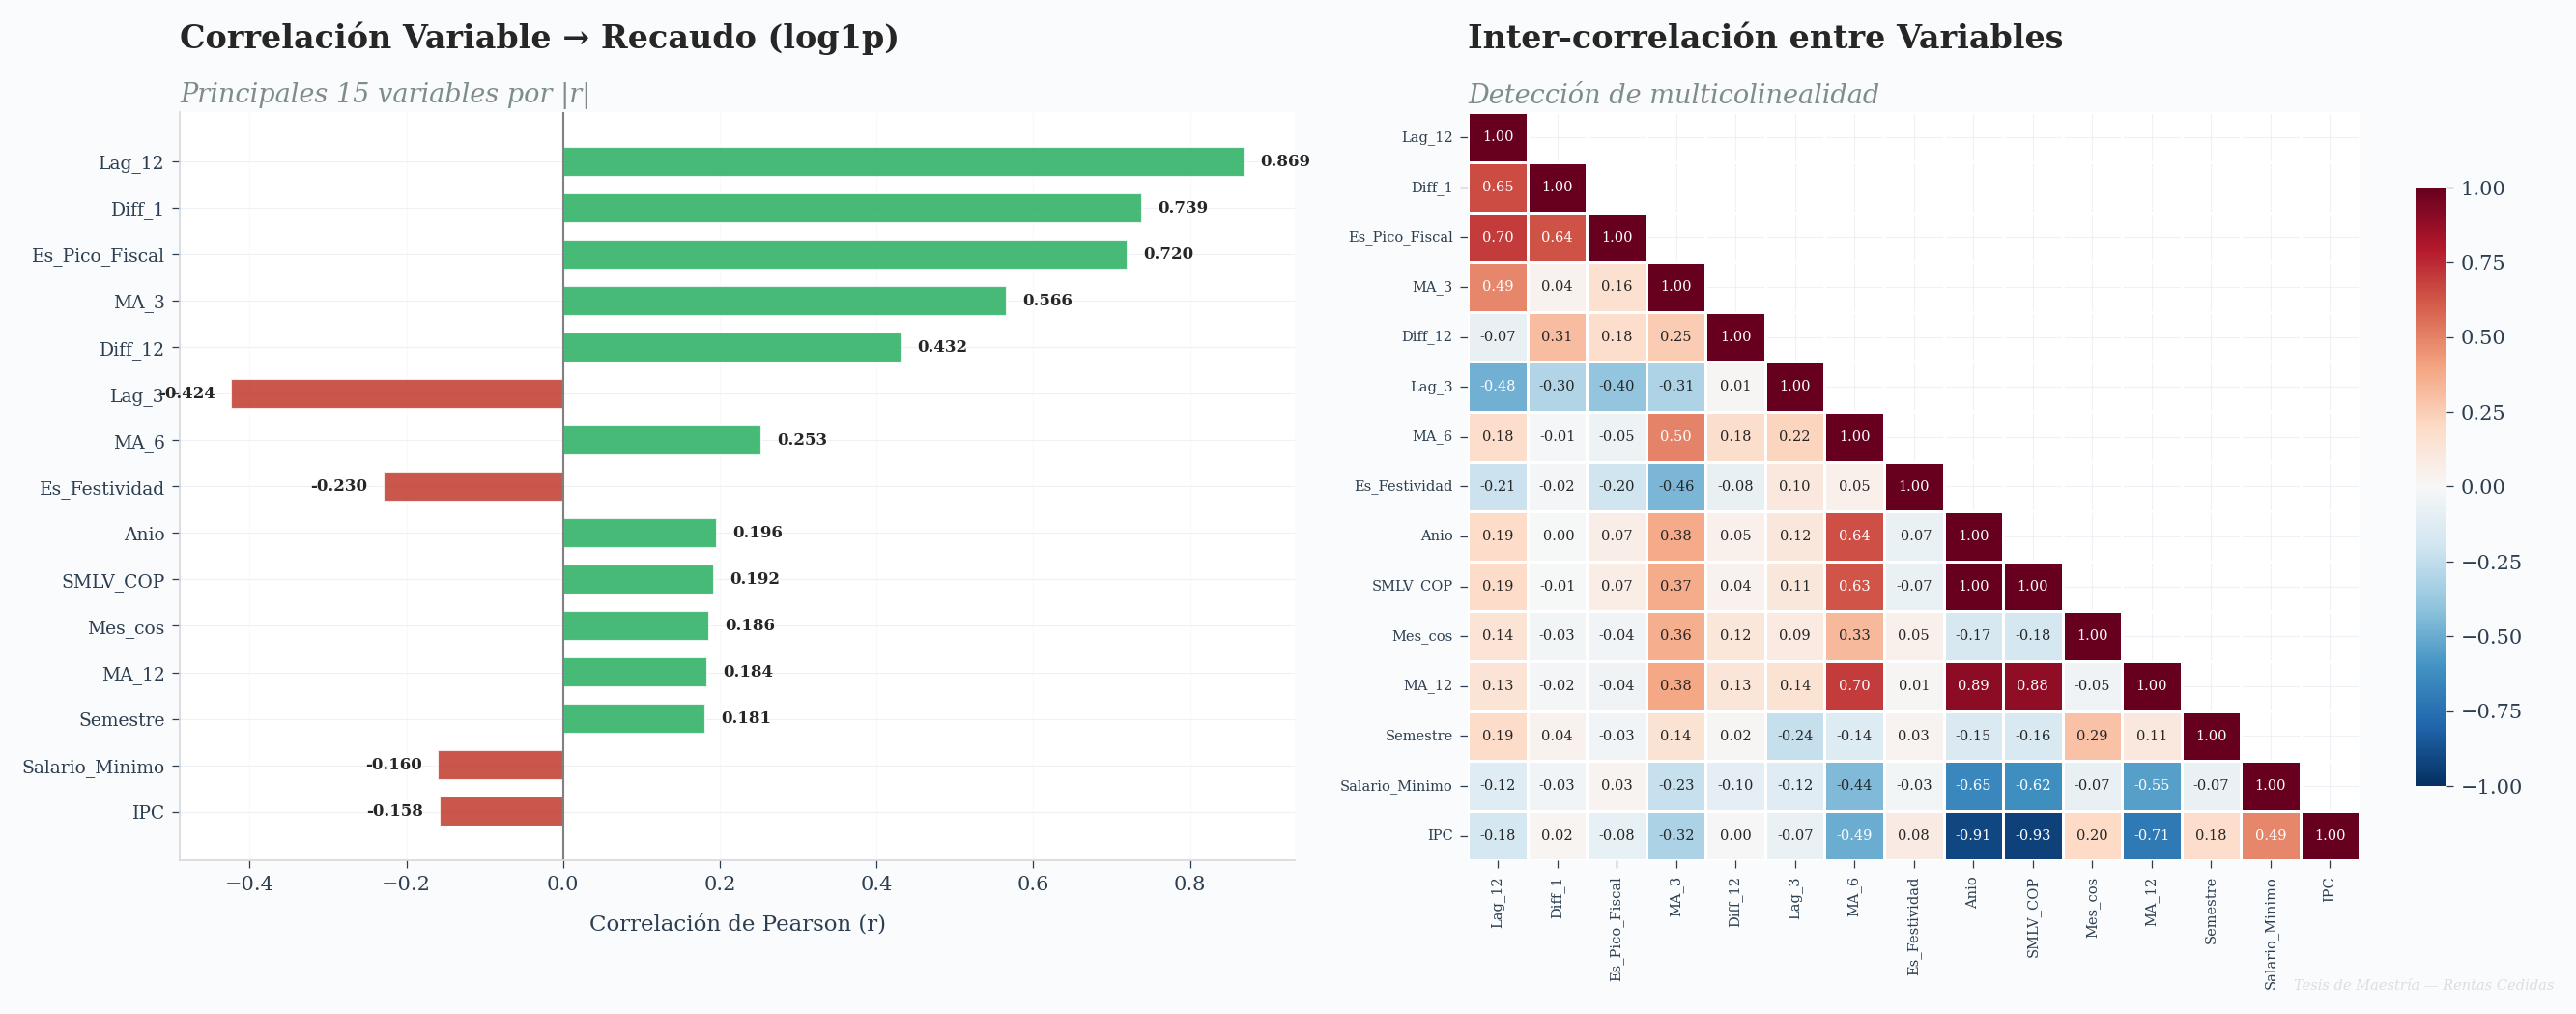


──────────────────────────────────────────────────────────────────────
DIAGNÓSTICO DE MULTICOLINEALIDAD
──────────────────────────────────────────────────────────────────────
  Anio                 ↔ SMLV_COP             r = +0.9982
  Trend                ↔ IPC_Idx              r = +0.9924
  Trend                ↔ Trend_sq             r = +0.9871
  Mes                  ↔ Trimestre            r = +0.9729
  Salario_Minimo       ↔ UPC                  r = +0.9636
  Trend_sq             ↔ IPC_Idx              r = +0.9614
  Anio                 ↔ Trend                r = +0.9513
  Anio                 ↔ IPC_Idx              r = +0.9501
  SMLV_COP             ↔ IPC_Idx              r = +0.9496
  Trend                ↔ SMLV_COP             r = +0.9450
  Trend_sq             ↔ MA_12                r = +0.9443
  Trend                ↔ MA_12                r = +0.9326
  IPC                  ↔ SMLV_COP             r = -0.9325
  Anio                 ↔ Trend_sq             r = +0.9266
  MA_12     

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE II — Exploración de Features y Correlación
# ══════════════════════════════════════════════════════════════

import seaborn as sns

# ── Correlación con variable objetivo ──
corr_target = df_clean[FEATURE_COLS + ['y']].corr()['y'].drop('y').sort_values(ascending=False)

print(f"{'═'*70}")
print(f"CORRELACIÓN DE VARIABLES CON VARIABLE OBJETIVO (log1p Recaudo)")
print(f"{'═'*70}")
for feat, r in corr_target.items():
    bar = '█' * int(abs(r) * 30)
    sign = '+' if r > 0 else '-'
    print(f"  {feat:<20} r = {r:+.4f}  {sign} {bar}")

# ── Heatmap de correlación (features seleccionadas) ──
top_features = corr_target.abs().nlargest(15).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Correlación con target
ax = axes[0]
colors = [C_QUATERNARY if v > 0 else C_SECONDARY for v in corr_target[top_features].values]
bars = ax.barh(range(len(top_features)), corr_target[top_features].values,
               color=colors, alpha=0.85, edgecolor='white', height=0.65)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=9)
ax.set_xlabel('Correlación de Pearson (r)', fontsize=11)
ax.invert_yaxis()
ax.axvline(0, color='grey', lw=1)
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, corr_target[top_features].values):
    offset = 0.02 if val >= 0 else -0.02
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=8, fontweight='bold')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Correlación Variable → Recaudo (log1p)',
                       f'Principales {len(top_features)} variables por |r|')
else:
    ax.set_title('Correlación Variable → Recaudo (log1p)', fontsize=13, fontweight='bold')

# Panel 2: Heatmap de inter-correlación
ax2 = axes[1]
corr_matrix = df_clean[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax2, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7}, linewidths=0.5)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'Inter-correlación entre Variables',
                       'Detección de multicolinealidad')
else:
    ax2.set_title('Inter-correlación entre Variables', fontsize=13, fontweight='bold')
ax2.tick_params(axis='both', labelsize=7)

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '06_xgboost_correlacion_features', OUTPUTS_FIGURES)
plt.show()

# ── Diagnóstico de multicolinealidad ──
print(f"\n{'─'*70}")
print(f"DIAGNÓSTICO DE MULTICOLINEALIDAD")
print(f"{'─'*70}")
high_corr_pairs = []
cols = FEATURE_COLS
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = df_clean[cols[i]].corr(df_clean[cols[j]])
        if abs(r) > 0.90:
            high_corr_pairs.append((cols[i], cols[j], r))
if high_corr_pairs:
    for a, b, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {a:<20} ↔ {b:<20} r = {r:+.4f}")
    print(f"\n  → XGBoost es robusto ante multicolinealidad (no afecta predicción)")
    print(f"    Sin embargo, la Importancia de Variables puede diluirse entre variables correlacionadas")
else:
    print(f"  No se detectaron pares con |r| > 0.90")

---

## Fase III — Optimización Bayesiana de Hiperparámetros

Se utiliza **Optuna** (Akiba et al., 2019) con validación cruzada temporal
(`TimeSeriesSplit`) para encontrar la configuración óptima de XGBoost.

### Espacio de Búsqueda

| Hiperparámetro | Rango | Justificación |
|----------------|-------|---------------|
| `n_estimators` | 50–500 | Número de árboles secuenciales |
| `max_depth` | 3–8 | Profundidad máxima (3–5 conservador, 6–8 agresivo) |
| `learning_rate` | 0.01–0.3 | Tasa de aprendizaje (shrinkage) |
| `subsample` | 0.6–1.0 | Fracción de muestras por árbol |
| `colsample_bytree` | 0.5–1.0 | Fracción de features por árbol |
| `min_child_weight` | 1–10 | Regularización: mínimo peso en hoja |
| `gamma` | 0–5 | Regularización: ganancia mínima para split |
| `reg_alpha` (L1) | 0–5 | Lasso regularization |
| `reg_lambda` (L2) | 0–5 | Ridge regularization |

### Validación Cruzada Temporal

Se usa `TimeSeriesSplit(n_splits=3)` para respetar la estructura temporal
y evitar data leakage. La métrica de optimización es **RMSE** sobre los
folds de validación.

> **Nota:** Optuna usa Tree-Structured Parzen Estimator (TPE) como
> sampler, más eficiente que GridSearch exhaustivo para espacios
> de alta dimensionalidad.

══════════════════════════════════════════════════════════════════════
OPTIMIZACIÓN BAYESIANA — Optuna (TPE Sampler)
══════════════════════════════════════════════════════════════════════
  Espacio: 9 hiperparámetros | CV: TimeSeriesSplit(3 folds)
  Trials: 200 (Tree-Structured Parzen Estimator)




──────────────────────────────────────────────────────────────────────
MEJOR CONFIGURACIÓN ENCONTRADA (Iteración #133)
──────────────────────────────────────────────────────────────────────
  n_estimators             : 152
  max_depth                : 5
  learning_rate            : 0.27828005449197507
  subsample                : 0.7569790468153137
  colsample_bytree         : 0.6052844886863629
  min_child_weight         : 3
  gamma                    : 0.0040299762609678335
  reg_alpha                : 0.44871974173647844
  reg_lambda               : 1.025395002311958
  CV RMSE (log1p):        0.147441


  📊 Figura guardada: 06_xgboost_optuna_convergencia.png


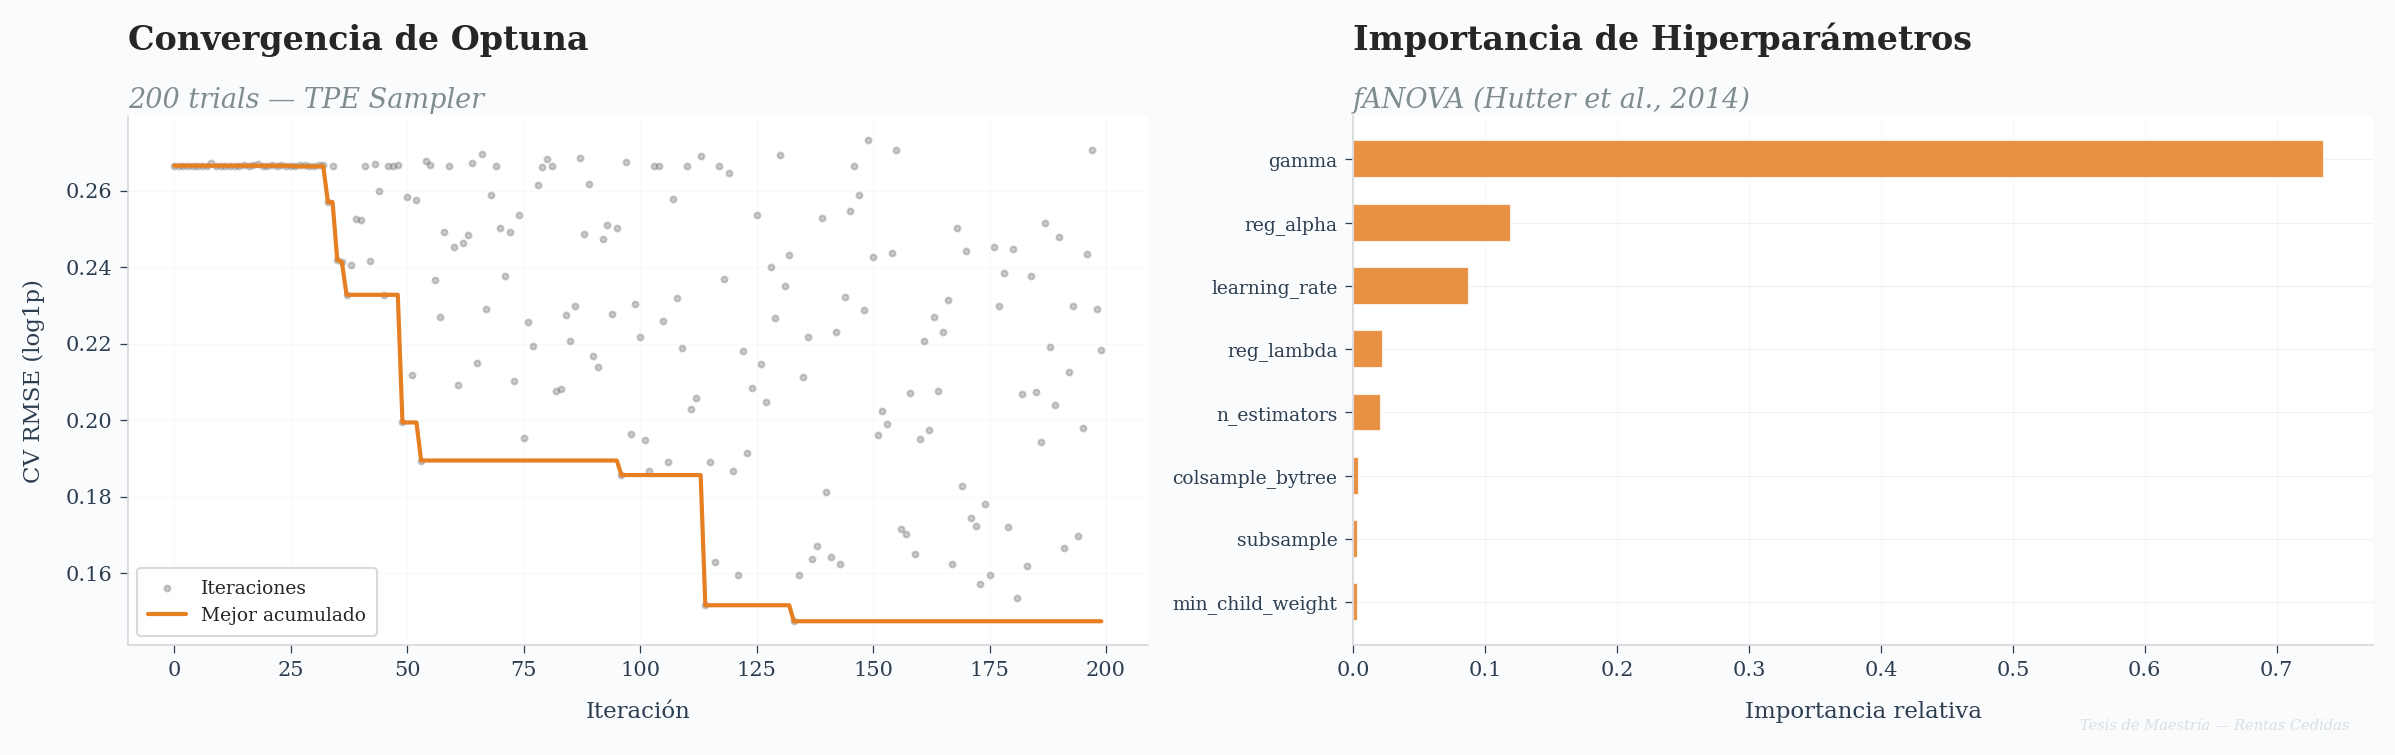


  ✅ Hiperparámetros óptimos seleccionados


In [3]:
# ══════════════════════════════════════════════════════════════
# FASE III — Optimización Bayesiana de Hiperparámetros (Optuna)
# ══════════════════════════════════════════════════════════════

# ── Validación cruzada temporal ──
tscv = TimeSeriesSplit(n_splits=3)

if OPTUNA_AVAILABLE:
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 5.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 5.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 5.0),
            'random_state': 42,
            'verbosity': 0,
        }
        
        rmses = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            
            y_pred = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            rmses.append(rmse)
        
        return np.mean(rmses)
    
    print(f"{'═'*70}")
    print(f"OPTIMIZACIÓN BAYESIANA — Optuna (TPE Sampler)")
    print(f"{'═'*70}")
    print(f"  Espacio: 9 hiperparámetros | CV: TimeSeriesSplit(3 folds)")
    print(f"  Trials: 200 (Tree-Structured Parzen Estimator)")
    print()
    
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=200, show_progress_bar=False)
    
    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['verbosity'] = 0
    
    print(f"\n{'─'*70}")
    print(f"MEJOR CONFIGURACIÓN ENCONTRADA (Iteración #{study.best_trial.number})")
    print(f"{'─'*70}")
    for k, v in best_params.items():
        if k not in ['random_state', 'verbosity']:
            print(f"  {k:<25}: {v}")
    print(f"  CV RMSE (log1p):        {study.best_value:.6f}")

else:
    # Fallback: GridSearch manual con parámetros razonables
    print(f"{'═'*70}")
    print(f"BÚSQUEDA DE HIPERPARÁMETROS — GridSearch Manual")
    print(f"{'═'*70}")
    
    param_grid = [
        {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
        {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
        {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9},
        {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.08, 'subsample': 0.7, 'colsample_bytree': 0.7},
        {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.85, 'colsample_bytree': 0.85},
    ]
    
    best_rmse = np.inf
    best_params = None
    for i, params in enumerate(param_grid):
        params.update({'min_child_weight': 3, 'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
                       'random_state': 42, 'verbosity': 0})
        rmses = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
            rmses.append(rmse)
        avg_rmse = np.mean(rmses)
        print(f"  Config {i+1}: n={params['n_estimators']}, depth={params['max_depth']}, "
              f"lr={params['learning_rate']} → RMSE={avg_rmse:.6f}")
        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_params = params.copy()
    
    print(f"\n  Mejor: RMSE = {best_rmse:.6f}")

# ── Visualización de convergencia (si Optuna) ──
if OPTUNA_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Panel 1: Historial de optimización
    ax = axes[0]
    trials = [t.value for t in study.trials]
    best_so_far = [min(trials[:i+1]) for i in range(len(trials))]
    ax.scatter(range(len(trials)), trials, s=8, alpha=0.4, color='grey', label='Iteraciones')
    ax.plot(best_so_far, color=C_QUINARY, lw=2, label='Mejor acumulado')
    ax.set_xlabel('Iteración', fontsize=11)
    ax.set_ylabel('CV RMSE (log1p)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Convergencia de Optuna',
                           f'{len(trials)} trials — TPE Sampler')
    else:
        ax.set_title('Convergencia de Optuna', fontsize=13, fontweight='bold')
    
    # Panel 2: Importancia de hiperparámetros
    ax2 = axes[1]
    try:
        param_importances = optuna.importance.get_param_importances(study)
        names = list(param_importances.keys())[:8]
        values = [param_importances[n] for n in names]
        ax2.barh(range(len(names)), values, color=C_QUINARY, alpha=0.85,
                 edgecolor='white', height=0.6)
        ax2.set_yticks(range(len(names)))
        ax2.set_yticklabels(names, fontsize=9)
        ax2.invert_yaxis()
        ax2.set_xlabel('Importancia relativa', fontsize=11)
        ax2.grid(True, alpha=0.3, axis='x')
        if _VIZ_THEME_LOADED:
            titulo_profesional(ax2, 'Importancia de Hiperparámetros',
                               'fANOVA (Hutter et al., 2014)')
        else:
            ax2.set_title('Importancia de Hiperparámetros', fontsize=13, fontweight='bold')
    except Exception:
        ax2.text(0.5, 0.5, 'Importancia de HP\nno disponible', ha='center',
                 va='center', fontsize=14, transform=ax2.transAxes)
    
    plt.tight_layout()
    if _VIZ_THEME_LOADED:
        marca_agua(fig)
        guardar_figura(fig, '06_xgboost_optuna_convergencia', OUTPUTS_FIGURES)
    plt.show()

print(f"\n  ✅ Hiperparámetros óptimos seleccionados")

---

## Fase IV -- Modelo Final: Entrenamiento y Validacion OOS

### Protocolo de evaluacion

Con los hiperparametros optimos de Fase III, se entrena el modelo final
sobre el conjunto de entrenamiento completo y se evalua contra datos
que el modelo **nunca vio**:

| Paso | Accion | Detalle |
|------|--------|---------|
| 1 | Entrenamiento | XGBRegressor con `best_params` sobre Oct 2021 - Sep 2025 |
| 2 | Prediccion OOS | Sobre X_test (Oct-Dic 2025, 3 meses) |
| 3 | Retransformacion | `expm1(y_pred)` para convertir de log1p a pesos COP |
| 4 | Metricas | MAPE, RMSE, MAE contra valores reales observados |
| 5 | Intervalos de confianza | Bootstrap de residuos (1,000 remuestreos) |

### Intervalos de Confianza via Bootstrap

A diferencia de SARIMAX y Prophet (que generan IC nativamente), XGBoost
no tiene distribucion parametrica de errores. Se construyen IC al 95%
mediante **bootstrap de residuos**: se remuestrean los errores del
entrenamiento y se suman a las predicciones, obteniendo los percentiles
2.5 y 97.5 de 1,000 escenarios.

══════════════════════════════════════════════════════════════════════
VALIDACIÓN OUT-OF-SAMPLE — XGBoost
══════════════════════════════════════════════════════════════════════
  Periodo test:  2025-10 → 2025-12 (3 meses)

──────────────────────────────────────────────────────────────────────
Mes                     Real      Pronóstico        Error   Error%
──────────────────────────────────────────────────────────────────────
  2025-10    $        313.0MM  $        294.6MM  $     -18.4MM    -5.9%
  2025-11    $        273.8MM  $        269.7MM  $      -4.1MM    -1.5%
  2025-12    $        241.0MM  $        222.2MM  $     -18.8MM    -7.8%
──────────────────────────────────────────────────────────────────────
  MAPE:  5.05%
  RMSE:  $15.4 MM COP
  MAE:   $13.8 MM COP


  📊 Figura guardada: 06_xgboost_oos_validacion.png


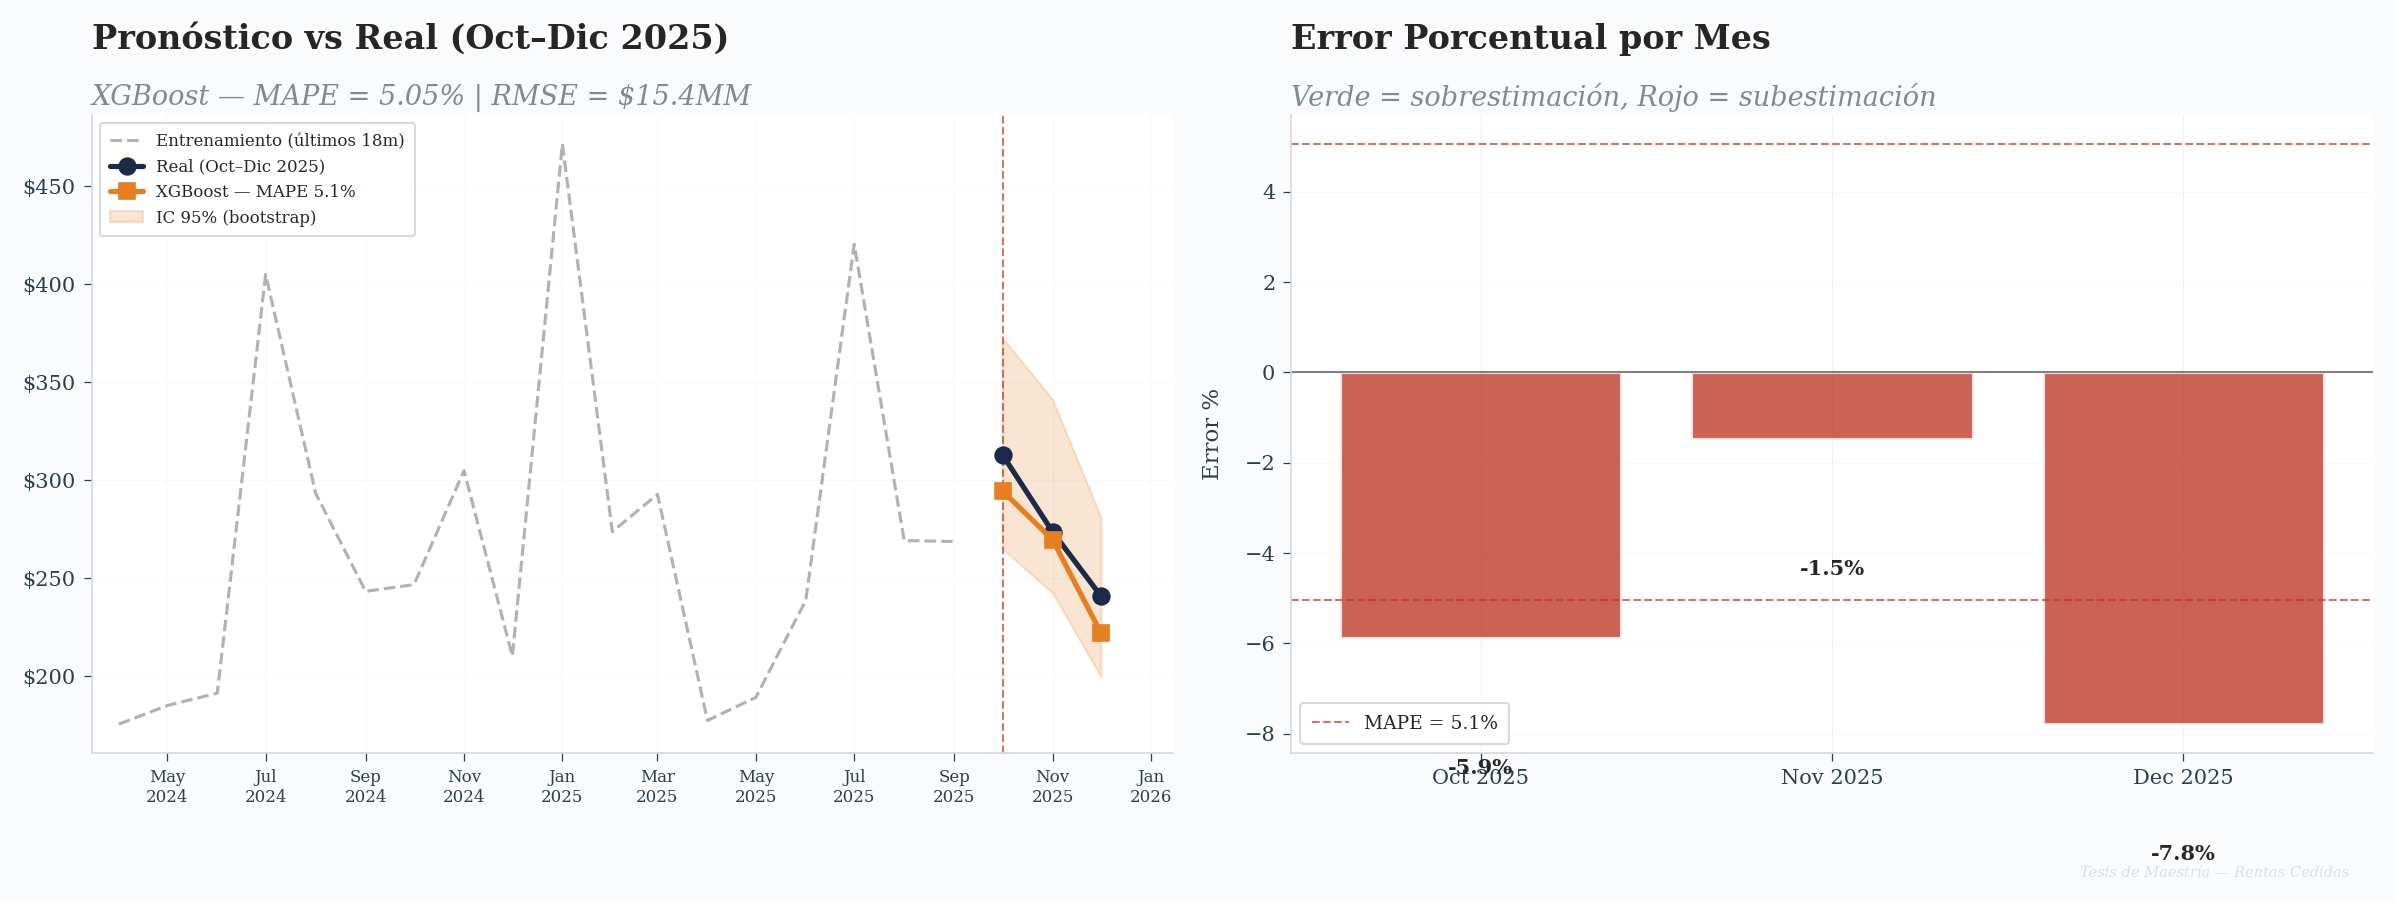


  ✅ Pronóstico OOS guardado: xgboost_forecast.csv


In [4]:
# ══════════════════════════════════════════════════════════════
# FASE IV — Modelo Final: Entrenamiento y Validación OOS
# ══════════════════════════════════════════════════════════════

# ── Entrenar modelo final con hiperparámetros óptimos ──
model_final = xgb.XGBRegressor(**best_params)
model_final.fit(X_train, y_train,
                eval_set=[(X_train, y_train), (X_test, y_test)],
                verbose=False)

# ── Predicción en escala log1p ──
y_pred_log = model_final.predict(X_test)

# ── Retransformar a escala real (pesos COP) ──
y_pred_real = np.expm1(y_pred_log)
y_real = y_test_raw.values

# ── Intervalos de confianza via bootstrap de residuos ──
y_train_pred_log = model_final.predict(X_train)
train_residuals = y_train.values - y_train_pred_log

N_BOOT = 1000
rng = np.random.RandomState(42)
boot_preds = np.array([y_pred_log + rng.choice(train_residuals, size=len(y_pred_log))
                       for _ in range(N_BOOT)])
ci_lower = np.maximum(0, np.expm1(np.percentile(boot_preds, 2.5, axis=0)))
ci_upper = np.expm1(np.percentile(boot_preds, 97.5, axis=0))

# ── Métricas OOS ──
mape = mean_absolute_percentage_error(y_real, y_pred_real) * 100
rmse = np.sqrt(mean_squared_error(y_real, y_pred_real))
mae  = mean_absolute_error(y_real, y_pred_real)

print(f"{'═'*70}")
print(f"VALIDACIÓN OUT-OF-SAMPLE — XGBoost")
print(f"{'═'*70}")
print(f"  Periodo test:  {X_test.index.min().strftime('%Y-%m')} → {X_test.index.max().strftime('%Y-%m')} ({len(X_test)} meses)")
print(f"\n{'─'*70}")
print(f"{'Mes':<12} {'Real':>15} {'Pronóstico':>15} {'Error':>12} {'Error%':>8}")
print(f"{'─'*70}")

for j, fecha in enumerate(X_test.index):
    real = y_real[j]
    pred = y_pred_real[j]
    err = pred - real
    err_pct = (pred - real) / real * 100
    print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM  ${pred/1e9:>13,.1f}MM  "
          f"${err/1e9:>10,.1f}MM  {err_pct:>6.1f}%")

print(f"{'─'*70}")
print(f"  MAPE:  {mape:.2f}%")
print(f"  RMSE:  ${rmse/1e9:.1f} MM COP")
print(f"  MAE:   ${mae/1e9:.1f} MM COP")

# ── Visualización: Real vs Pronóstico ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Contexto histórico + OOS
ax = axes[0]
n_hist = min(18, len(y_train))
train_dates = X_train.index[-n_hist:]
train_vals = y_train_raw.values[-n_hist:]
ax.plot(train_dates, train_vals/1e9, color='grey', lw=1.5, ls='--',
        alpha=0.6, label='Entrenamiento (últimos 18m)')
ax.plot(X_test.index, y_real/1e9, color=C_PRIMARY, lw=2.5,
        marker='o', markersize=8, label='Real (Oct–Dic 2025)', zorder=5)
ax.plot(X_test.index, y_pred_real/1e9, color=C_QUINARY, lw=2.5,
        marker='s', markersize=8, label=f'XGBoost — MAPE {mape:.1f}%', zorder=5)
ax.fill_between(X_test.index, ci_lower/1e9, ci_upper/1e9,
                color=C_QUINARY, alpha=0.20, label='IC 95% (bootstrap)', zorder=2)
ax.axvline(pd.Timestamp(TEST_START), color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper left')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Pronóstico vs Real (Oct–Dic 2025)',
                       f'XGBoost — MAPE = {mape:.2f}% | RMSE = ${rmse/1e9:.1f}MM')
    formato_pesos_eje(ax, eje='y')
else:
    ax.set_title(f'XGBoost — Validación OOS (MAPE={mape:.2f}%)',
                 fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(formato_pesos))

# Panel 2: Barras de error porcentual
ax2 = axes[1]
meses_label = [f.strftime('%b %Y') for f in X_test.index]
errores_pct = [(y_pred_real[k] - y_real[k]) / y_real[k] * 100
               for k in range(len(y_real))]
clr_pos, clr_neg = '#27AE60', '#C0392B'
colors_bar = [clr_pos if e >= 0 else clr_neg for e in errores_pct]
ax2.bar(meses_label, errores_pct, color=colors_bar, alpha=0.8,
        edgecolor='white', lw=1.5)
ax2.axhline(0, color='grey', lw=1)
ax2.axhline(mape, color=C_SECONDARY, ls='--', lw=1, alpha=0.7,
            label=f'MAPE = {mape:.1f}%')
ax2.axhline(-mape, color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
for k, (m, e) in enumerate(zip(meses_label, errores_pct)):
    offset = 1.5 if e >= 0 else -3
    ax2.text(k, e + offset, f'{e:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Error %', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=9)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'Error Porcentual por Mes',
                       'Verde = sobrestimación, Rojo = subestimación')
else:
    ax2.set_title('Error % por Mes', fontsize=12, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '06_xgboost_oos_validacion', OUTPUTS_FIGURES)
plt.show()

# ── Guardar pronóstico OOS ──
df_oos = pd.DataFrame({
    'Fecha': X_test.index,
    'Real': y_real,
    'Pronostico_XGBoost': y_pred_real,
    'IC_Inferior': ci_lower,
    'IC_Superior': ci_upper,
    'Error_Abs': np.abs(y_pred_real - y_real),
    'Error_Pct': (y_pred_real - y_real) / y_real * 100
})
df_oos.to_csv(OUTPUTS_FORECASTS / 'xgboost_forecast.csv', index=False)
print(f"\n  ✅ Pronóstico OOS guardado: xgboost_forecast.csv")

---

## Fase V -- Feature Importance y Analisis SHAP

### Dos niveles de interpretabilidad

Uno de los mayores retos del Machine Learning es la "caja negra": el modelo
predice bien, pero no sabemos por que. XGBoost ofrece dos herramientas
complementarias para abrir la caja:

| Herramienta | Pregunta que responde | Nivel |
|-------------|----------------------|-------|
| **Feature Importance (Gain)** | Que variables son mas importantes en general? | Global |
| **SHAP Values** (Lundberg & Lee, 2017) | Por que el modelo predijo X para este mes especifico? | Local |

### Feature Importance por Gain

El Gain mide cuanta reduccion de error aporta cada variable cuando se usa
para dividir un nodo del arbol. Si el IPC tiene el mayor Gain, significa
que las decisiones basadas en el IPC son las que mas reducen el error
de prediccion.

### SHAP: Explicacion de predicciones individuales

SHAP (SHapley Additive exPlanations) descompone **cada prediccion individual**
en la contribucion de cada variable. Basado en teoria de juegos cooperativos
(Shapley, 1953), garantiza que las contribuciones suman exactamente la
prediccion total:

$$\hat{y}_i = \phi_0 + \sum_{j=1}^{M} \phi_j^{(i)}$$

donde $\phi_0$ es el valor base (media) y $\phi_j^{(i)}$ es la contribucion
de la feature $j$ a la prediccion del mes $i$.

> **Relevancia para ADRES:** Si el IPC domina el Feature Importance, confirma
> que el recaudo esta fuertemente ligado a la inflacion, lo cual tiene
> implicaciones directas para la politica de rentas cedidas.

══════════════════════════════════════════════════════════════════════
IMPORTANCIA DE VARIABLES (Ganancia) — XGBoost
══════════════════════════════════════════════════════════════════════
  MA_3                  29.65%  █████████████████████████████
  Lag_12                27.20%  ███████████████████████████
  Diff_1                14.17%  ██████████████
  Es_Pico_Fiscal         7.74%  ███████
  Trend                  6.57%  ██████
  Mes_sin                5.51%  █████
  MA_12                  4.12%  ████
  Diff_12                3.33%  ███
  Lag_2                  0.85%  
  Lag_1                  0.85%  

──────────────────────────────────────────────────────────────────────
DISTRIBUCIÓN POR TIPO DE VARIABLE
──────────────────────────────────────────────────────────────────────
  Macroeconómicas:      0.0% 
  Lags / Momentum:     80.2% MA_3, Lag_12, Diff_1, MA_12, Diff_12, Lag_2, Lag_1
  Calendario:          13.3% Es_Pico_Fiscal, Mes_sin
  Tendencia:            6.6%


  📊 Figura guardada: 06_xgboost_feature_importance.png


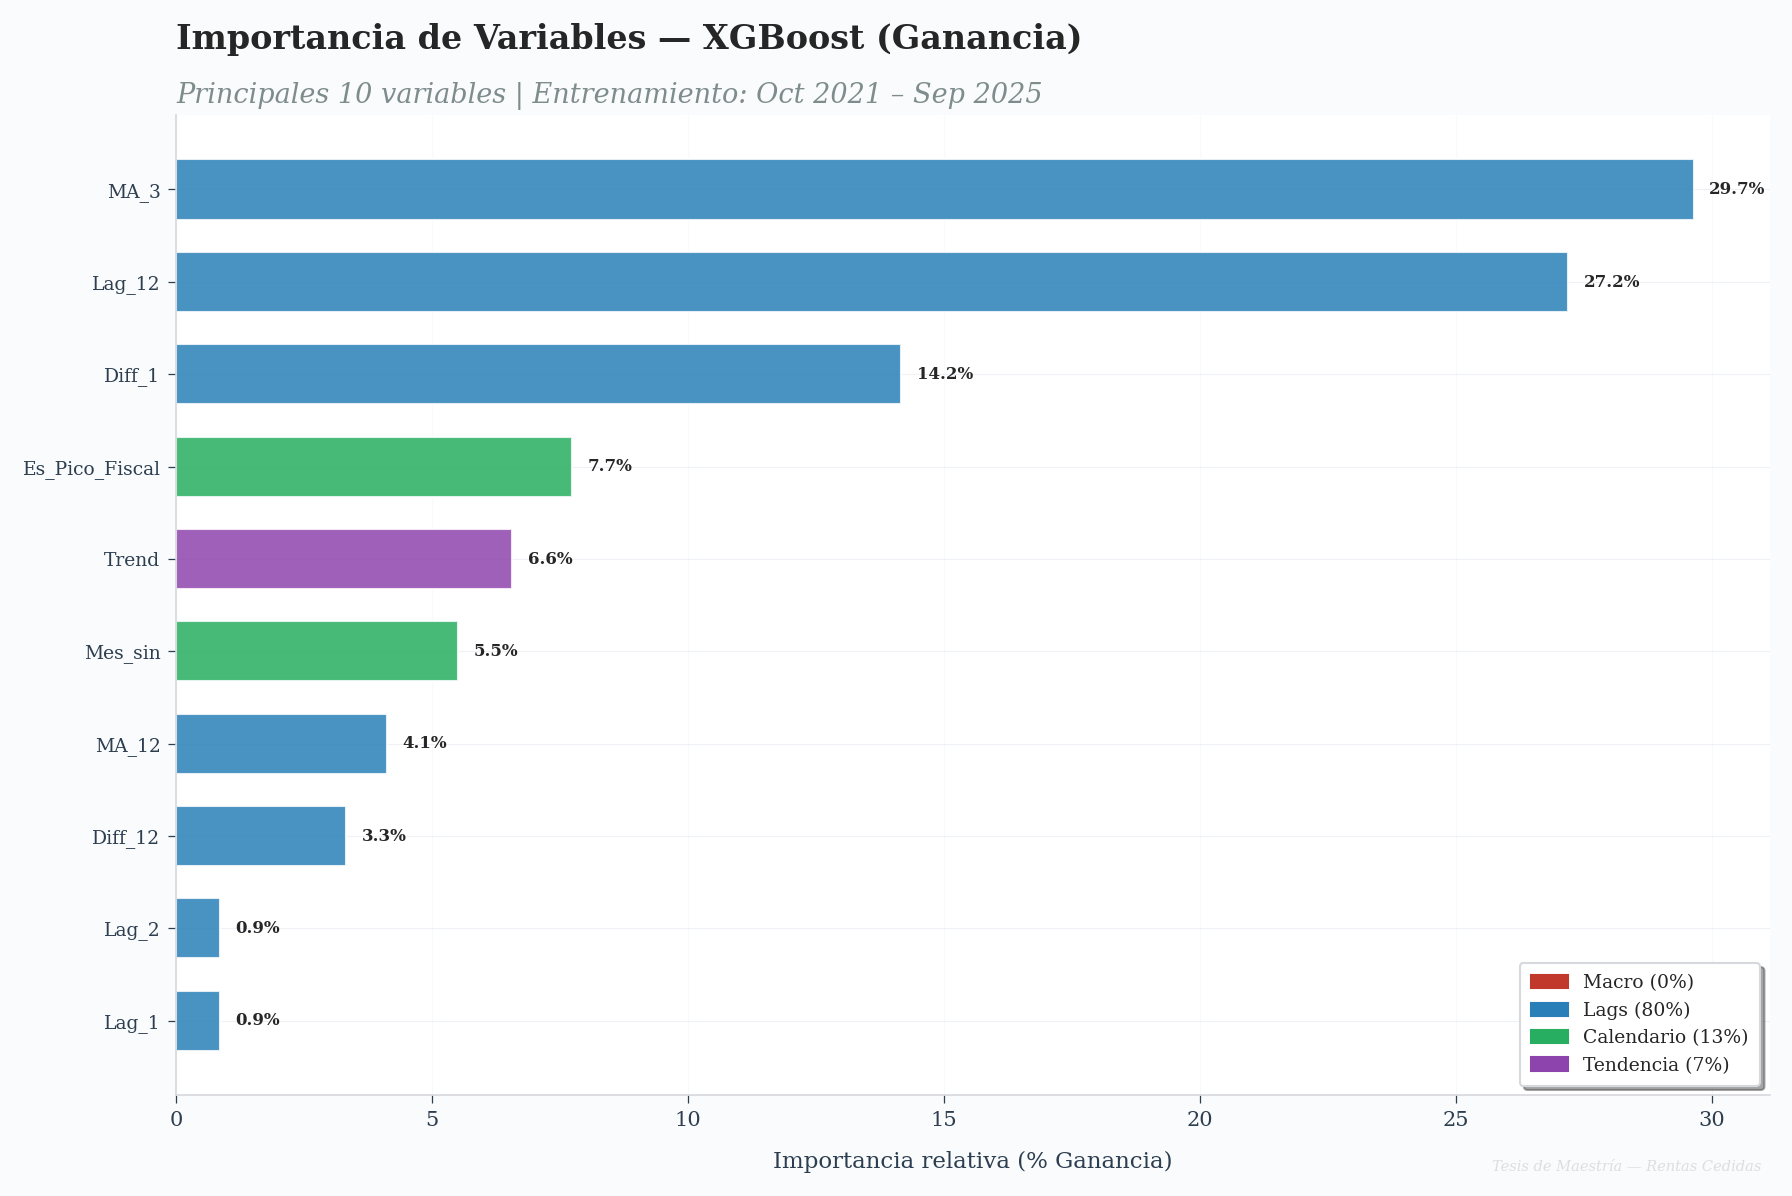


══════════════════════════════════════════════════════════════════════
VALORES SHAP — Contribución Local de Cada Variable
══════════════════════════════════════════════════════════════════════


  📊 Figura guardada: 06_xgboost_shap.png


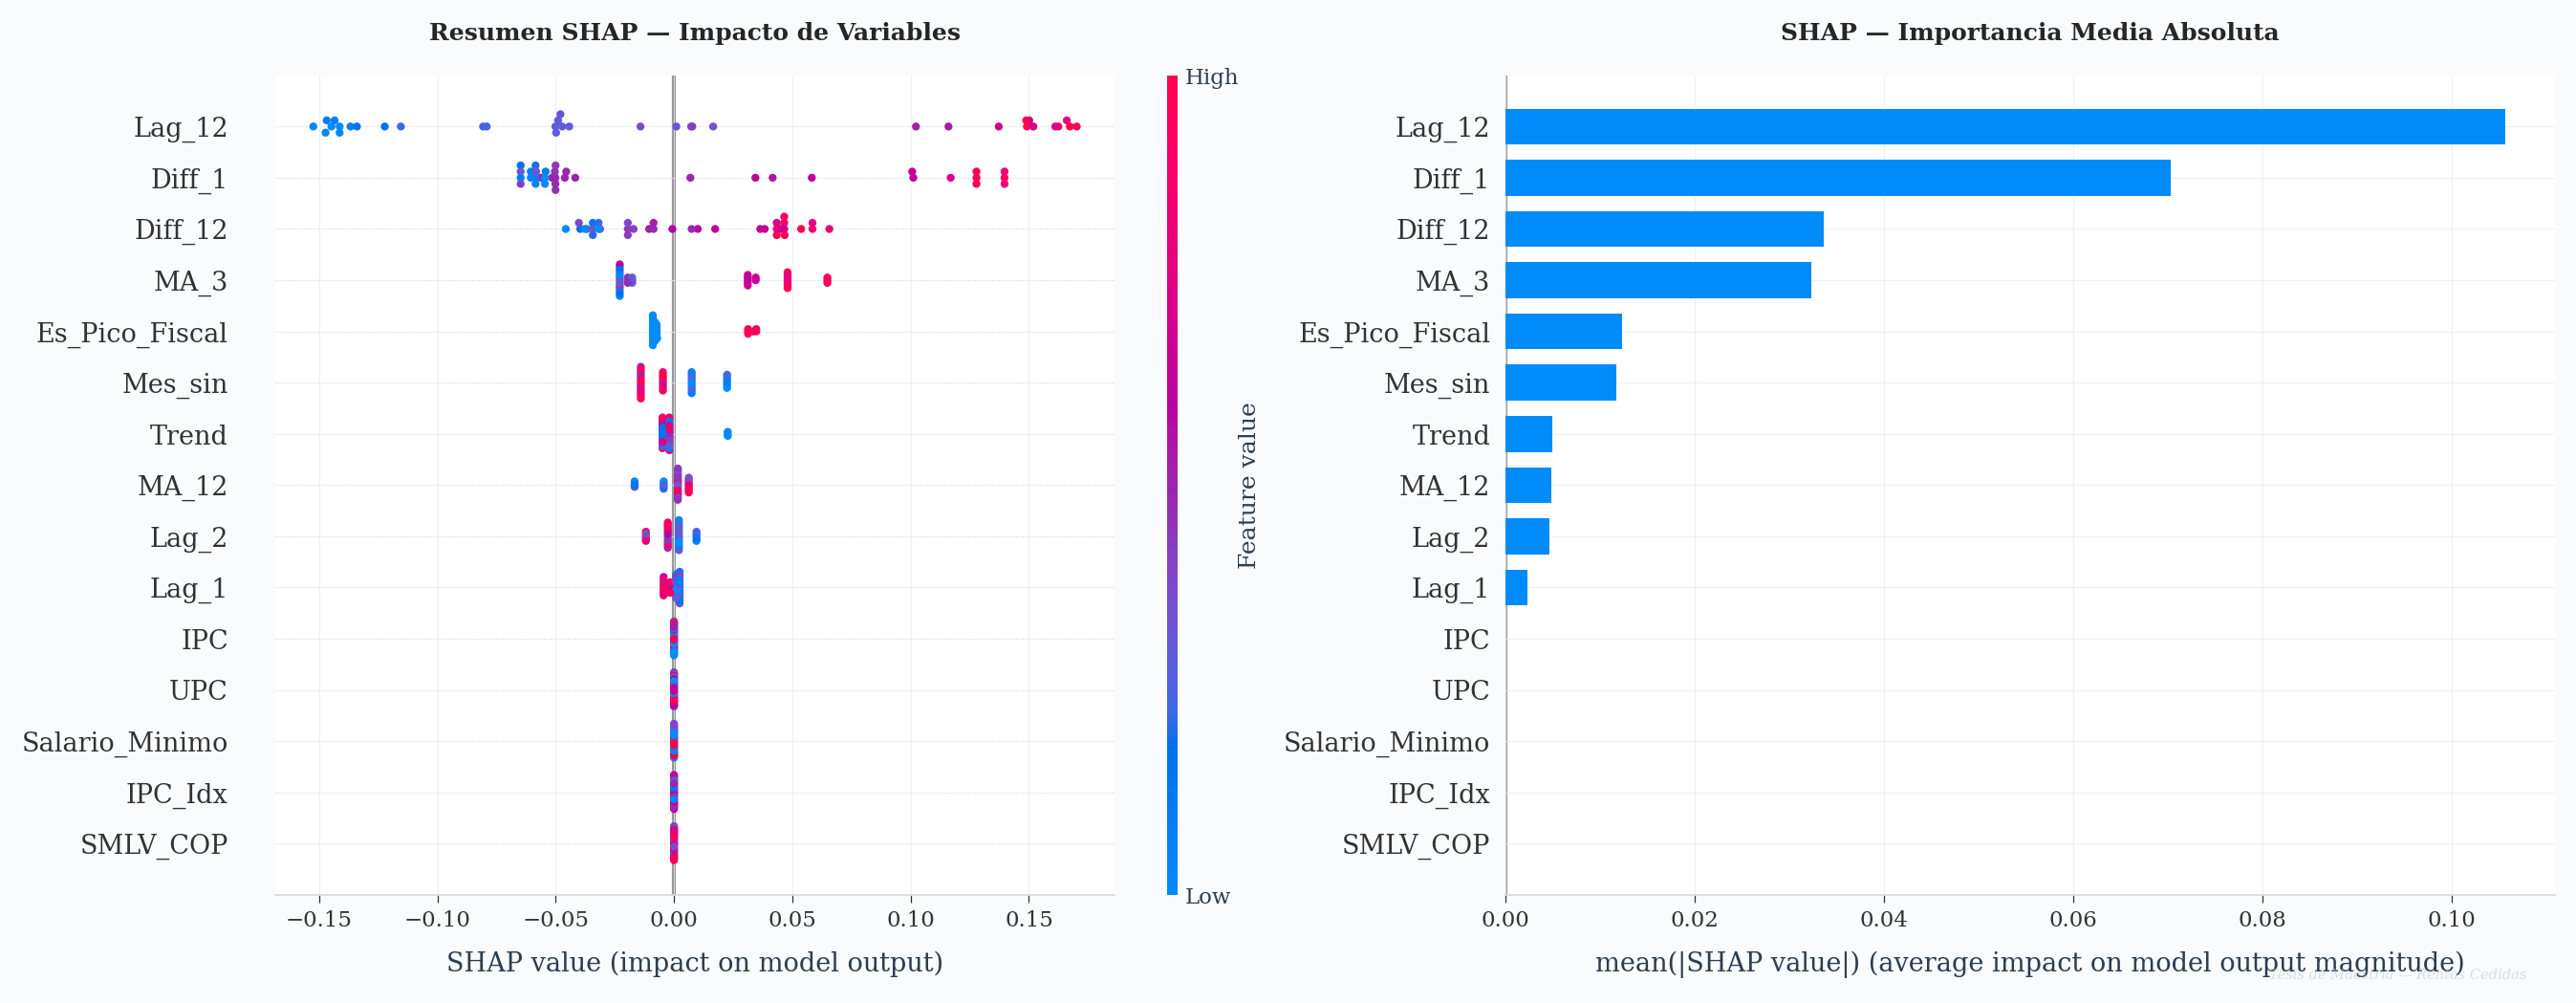


  Contribuciones SHAP para cada mes OOS:

  2025-10 (Pred: $294.6MM)
    Diff_1               SHAP = +0.0583
    Diff_12              SHAP = +0.0537
    MA_3                 SHAP = +0.0312
    Mes_sin              SHAP = +0.0075
    Es_Pico_Fiscal       SHAP = -0.0073

  2025-11 (Pred: $269.7MM)
    Lag_12               SHAP = +0.1372
    Diff_1               SHAP = -0.0648
    MA_3                 SHAP = +0.0480
    Diff_12              SHAP = -0.0396
    Lag_2                SHAP = -0.0119

  2025-12 (Pred: $222.2MM)
    Lag_12               SHAP = -0.1174
    Diff_1               SHAP = -0.0583
    Diff_12              SHAP = +0.0466
    MA_3                 SHAP = +0.0312
    Mes_sin              SHAP = -0.0140

  ✅ Análisis de importancia completado


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE V — Feature Importance + SHAP
# ══════════════════════════════════════════════════════════════

# ── Feature Importance por Gain ──
importance = model_final.get_booster().get_score(importance_type='gain')
df_imp = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Gain': list(importance.values())
}).sort_values('Gain', ascending=False)

# Mapear nombres de features (XGBoost usa f0, f1... a veces)
if df_imp['Feature'].str.startswith('f').all():
    df_imp['Feature'] = [FEATURE_COLS[int(f[1:])] for f in df_imp['Feature']]

# Normalizar a porcentaje
df_imp['Gain_pct'] = df_imp['Gain'] / df_imp['Gain'].sum() * 100

print(f"{'═'*70}")
print(f"IMPORTANCIA DE VARIABLES (Ganancia) — XGBoost")
print(f"{'═'*70}")
for _, row in df_imp.iterrows():
    bar = '█' * int(row['Gain_pct'])
    print(f"  {row['Feature']:<20} {row['Gain_pct']:6.2f}%  {bar}")

# ── Clasificar por tipo de feature ──
macro_features = [f for f in df_imp['Feature'] if f in MACRO_VARS]
lag_features = [f for f in df_imp['Feature'] if 'Lag' in f or 'MA_' in f or 'Diff' in f]
cal_features = [f for f in df_imp['Feature'] if f in ['Mes', 'Trimestre', 'Anio',
                'Es_Pico_Fiscal', 'Es_Festividad', 'Semestre', 'Mes_sin', 'Mes_cos']]

macro_pct = df_imp[df_imp['Feature'].isin(macro_features)]['Gain_pct'].sum()
lag_pct = df_imp[df_imp['Feature'].isin(lag_features)]['Gain_pct'].sum()
cal_pct = df_imp[df_imp['Feature'].isin(cal_features)]['Gain_pct'].sum()
trend_pct = df_imp[df_imp['Feature'].isin(['Trend', 'Trend_sq'])]['Gain_pct'].sum()

print(f"\n{'─'*70}")
print(f"DISTRIBUCIÓN POR TIPO DE VARIABLE")
print(f"{'─'*70}")
print(f"  Macroeconómicas:   {macro_pct:6.1f}% {', '.join(macro_features)}")
print(f"  Lags / Momentum:   {lag_pct:6.1f}% {', '.join(lag_features)}")
print(f"  Calendario:        {cal_pct:6.1f}% {', '.join(cal_features)}")
print(f"  Tendencia:         {trend_pct:6.1f}%")

# ── Visualización: Feature Importance ──
fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(20, len(df_imp))
top_df = df_imp.head(top_n).iloc[::-1]

# Color por tipo
def get_color(feat):
    if feat in MACRO_VARS: return C_SECONDARY
    if 'Lag' in feat or 'MA_' in feat or 'Diff' in feat: return C_TERTIARY
    if feat in ['Mes', 'Trimestre', 'Anio', 'Semestre', 'Es_Pico_Fiscal',
                'Es_Festividad', 'Mes_sin', 'Mes_cos']: return C_QUATERNARY
    if feat in ['Trend', 'Trend_sq']: return C_SENARY
    return 'grey'

colors = [get_color(f) for f in top_df['Feature']]
bars = ax.barh(range(len(top_df)), top_df['Gain_pct'].values,
               color=colors, alpha=0.85, edgecolor='white', height=0.65)
ax.set_yticks(range(len(top_df)))
ax.set_yticklabels(top_df['Feature'].values, fontsize=9)
ax.set_xlabel('Importancia relativa (% Ganancia)', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

for bar, pct in zip(bars, top_df['Gain_pct'].values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8, fontweight='bold')

# Leyenda por color
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=C_SECONDARY, label=f'Macro ({macro_pct:.0f}%)'),
    mpatches.Patch(color=C_TERTIARY, label=f'Lags ({lag_pct:.0f}%)'),
    mpatches.Patch(color=C_QUATERNARY, label=f'Calendario ({cal_pct:.0f}%)'),
    mpatches.Patch(color=C_SENARY, label=f'Tendencia ({trend_pct:.0f}%)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          frameon=True, fancybox=True, shadow=True)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Importancia de Variables — XGBoost (Ganancia)',
                       f'Principales {top_n} variables | Entrenamiento: Oct 2021 – Sep 2025')
else:
    ax.set_title(f'Importancia de Variables — XGBoost (Principales {top_n})',
                 fontsize=14, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '06_xgboost_feature_importance', OUTPUTS_FIGURES)
plt.show()

# ══════════════════════════════════════════════════════════════
# SHAP Analysis (si disponible)
# ══════════════════════════════════════════════════════════════
if SHAP_AVAILABLE:
    print(f"\n{'═'*70}")
    print(f"VALORES SHAP — Contribución Local de Cada Variable")
    print(f"{'═'*70}")
    
    explainer = shap.TreeExplainer(model_final)
    shap_values = explainer.shap_values(X_train)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Panel 1: Summary plot (beeswarm)
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_train, max_display=15, show=False,
                      plot_size=None)
    axes[0].set_title('Resumen SHAP — Impacto de Variables', fontsize=12, fontweight='bold')
    
    # Panel 2: Mean absolute SHAP
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_train, plot_type='bar', max_display=15,
                      show=False, plot_size=None)
    axes[1].set_title('SHAP — Importancia Media Absoluta', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    if _VIZ_THEME_LOADED:
        marca_agua(fig)
        guardar_figura(fig, '06_xgboost_shap', OUTPUTS_FIGURES)
    plt.show()
    
    # ── SHAP para predicciones del test ──
    shap_test = explainer.shap_values(X_test)
    print(f"\n  Contribuciones SHAP para cada mes OOS:")
    for j, fecha in enumerate(X_test.index):
        print(f"\n  {fecha.strftime('%Y-%m')} (Pred: ${y_pred_real[j]/1e9:.1f}MM)")
        top_shap_idx = np.argsort(np.abs(shap_test[j]))[-5:][::-1]
        for idx in top_shap_idx:
            feat = FEATURE_COLS[idx]
            val = shap_test[j][idx]
            print(f"    {feat:<20} SHAP = {val:+.4f}")
else:
    print(f"\n  ℹ️ SHAP no disponible — solo Importancia de Variables nativa")

print(f"\n  ✅ Análisis de importancia completado")

---

## Fase VI -- Comparativa Head-to-Head: XGBoost vs SARIMAX vs Prophet

### Por que comparar sobre el mismo periodo

La comparacion solo es valida si todos los modelos predicen **exactamente
los mismos 3 meses** (Oct-Dic 2025) con datos reales. Cualquier diferencia
en el periodo de evaluacion invalida la comparacion.

### Triada de metricas

| Metrica | Formula | Unidad | Para quien es util |
|---------|---------|--------|-------------------|
| **MAPE** | $\frac{1}{n}\sum|\frac{y_i - \hat{y}_i}{y_i}| \times 100$ | % | Alta gerencia (error relativo) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | MM COP | Analistas (penaliza picos) |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | MM COP | Operaciones (desvio promedio) |

### Escala de interpretacion MAPE para ADRES

| Rango MAPE | Calificacion | Implicacion operativa |
|------------|-------------|----------------------|
| < 5% | Excelente | Pronostico confiable para balance de caja |
| 5-10% | Bueno | Margen de ajuste aceptable |
| 10-15% | Aceptable | Requiere revision mensual |
| > 15% | Insuficiente | No apto para decision presupuestal |

> **MAPE como metrica principal:** Normaliza el error por la magnitud del
> recaudo, lo que permite comparar periodos de distinto volumen (Oct vs Ene).

══════════════════════════════════════════════════════════════════════
COMPARATIVA HEAD-TO-HEAD — Validación Oct–Dic 2025
══════════════════════════════════════════════════════════════════════
       Modelo  MAPE  RMSE_MM  MAE_MM
Rank                                
1     XGBoost  5.05     15.4    13.8
2     Prophet  6.30     28.7    19.3
3     SARIMAX  9.75     37.0    28.9

──────────────────────────────────────────────────────────────────────
MODELO LÍDER: XGBoost
──────────────────────────────────────────────────────────────────────
  MAPE:   5.05%
  RMSE:   $15.4 MM
  MAE:    $13.8 MM


  📊 Figura guardada: 06_xgboost_comparativa_modelos.png


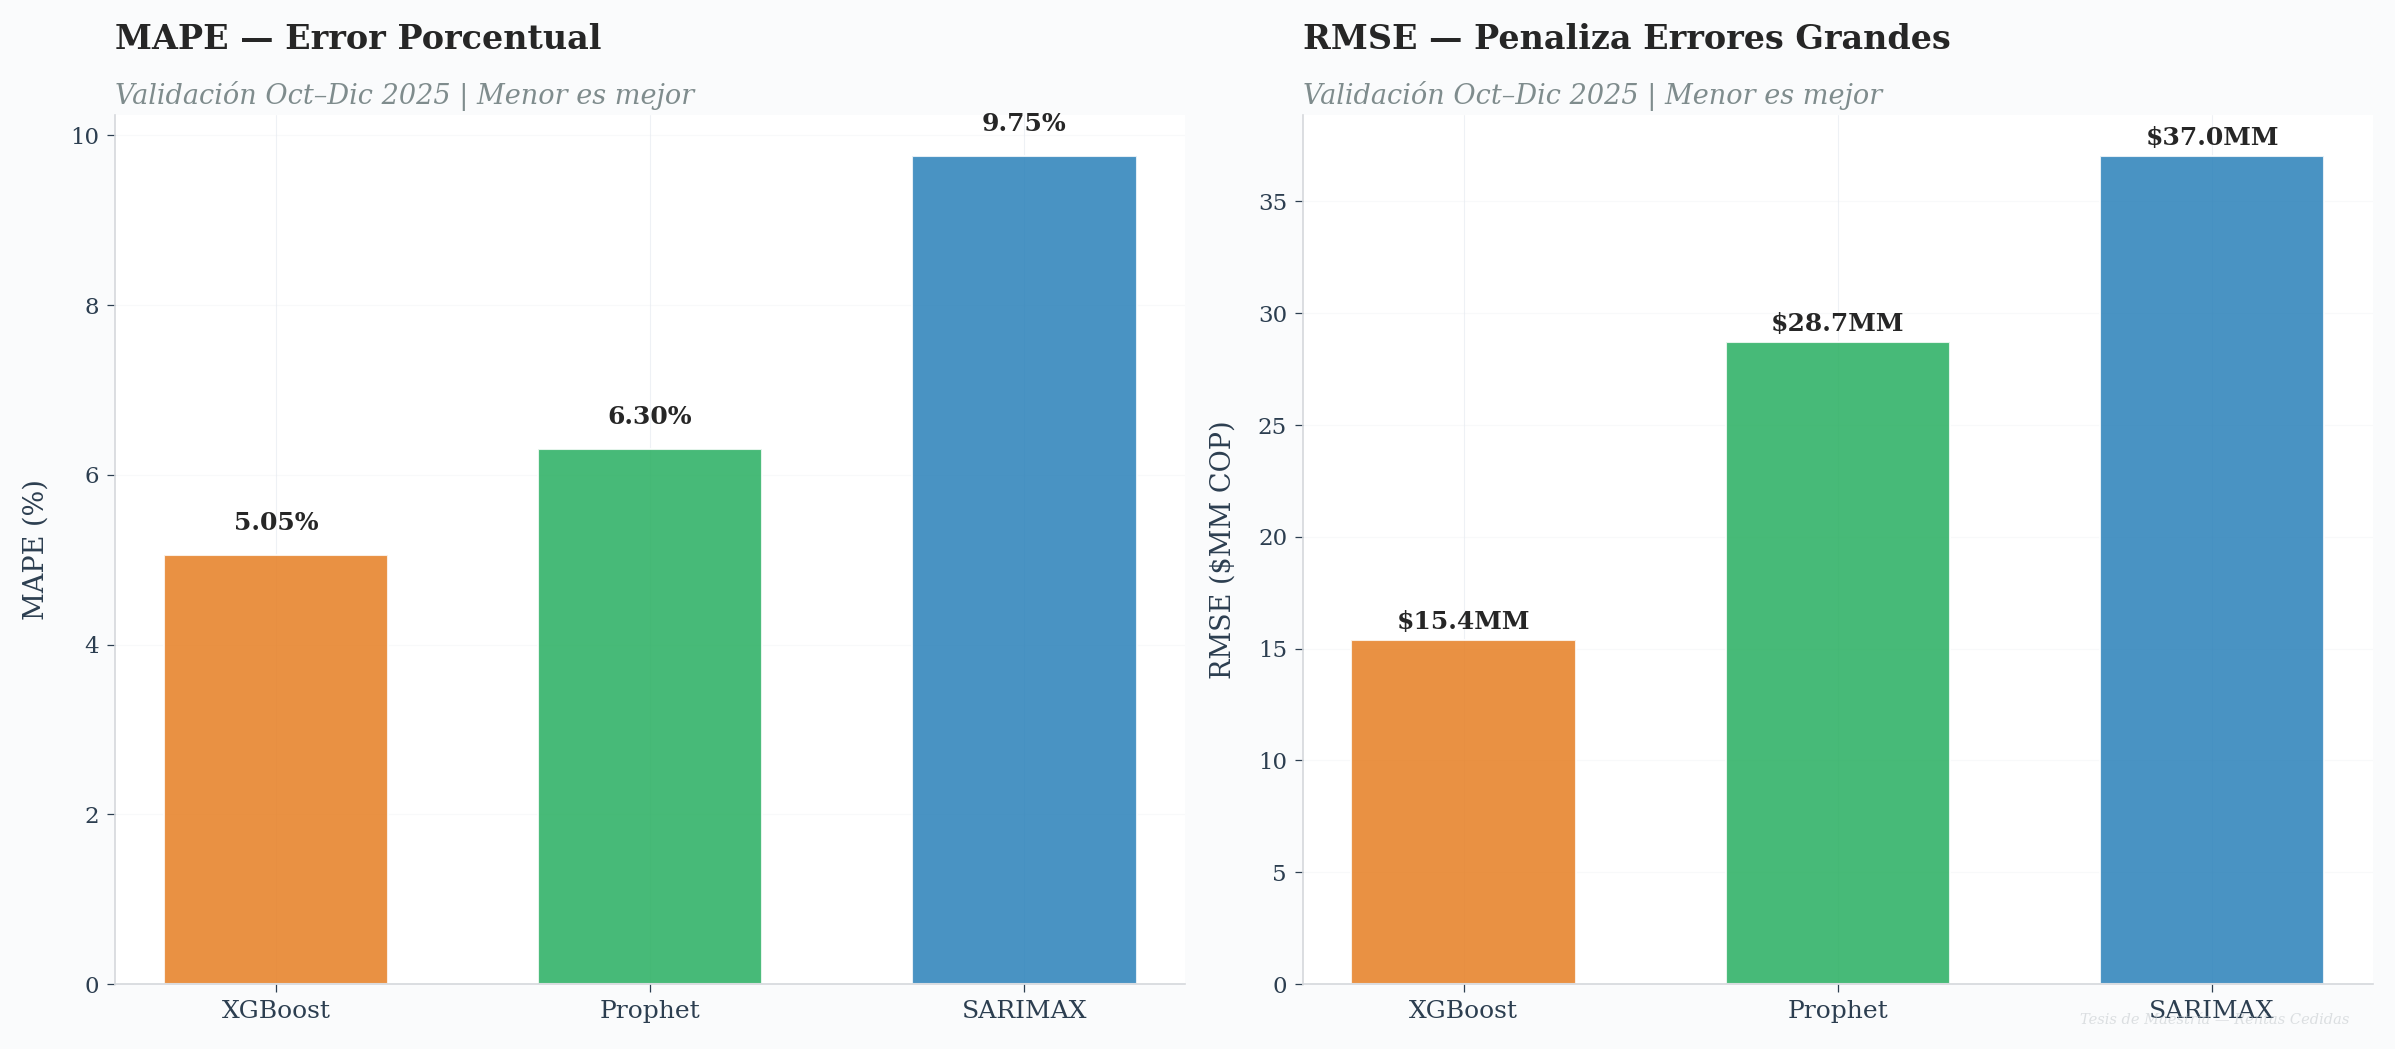


  ✅ Tabla comparativa guardada: comparacion_xgboost_vs_lineales.csv


In [6]:
# ══════════════════════════════════════════════════════════════
# FASE VI — Comparativa Head-to-Head (solo validación OOS)
# ══════════════════════════════════════════════════════════════

# ── Cargar métricas de los otros modelos ──
comparativa = []

# XGBoost (este modelo)
comparativa.append({
    'Modelo': 'XGBoost',
    'MAPE': round(mape, 2),
    'RMSE_MM': round(rmse / 1e9, 1),
    'MAE_MM': round(mae / 1e9, 1),
})

# SARIMAX
try:
    df_sarimax = pd.read_csv(OUTPUTS_REPORTS / 'sarimax_metricas.csv')
    comparativa.append({
        'Modelo': 'SARIMAX',
        'MAPE': df_sarimax['MAPE'].values[0],
        'RMSE_MM': df_sarimax['RMSE_MM'].values[0],
        'MAE_MM': df_sarimax['MAE_MM'].values[0],
    })
except FileNotFoundError:
    print("  ⚠️ sarimax_metricas.csv no encontrado")

# Prophet
try:
    df_prophet = pd.read_csv(OUTPUTS_REPORTS / 'prophet_metricas.csv')
    comparativa.append({
        'Modelo': 'Prophet',
        'MAPE': df_prophet['MAPE'].values[0],
        'RMSE_MM': df_prophet['RMSE_MM'].values[0],
        'MAE_MM': df_prophet['MAE_MM'].values[0],
    })
except FileNotFoundError:
    print("  ⚠️ prophet_metricas.csv no encontrado")

# ── Tabla comparativa ──
df_comp = pd.DataFrame(comparativa).sort_values('MAPE')
df_comp.index = range(1, len(df_comp) + 1)
df_comp.index.name = 'Rank'

print(f"{'═'*70}")
print(f"COMPARATIVA HEAD-TO-HEAD — Validación Oct–Dic 2025")
print(f"{'═'*70}")
print(df_comp.to_string())

# ── Mejor modelo ──
best_model = df_comp.iloc[0]
print(f"\n{'─'*70}")
print(f"MODELO LÍDER: {best_model['Modelo']}")
print(f"{'─'*70}")
print(f"  MAPE:   {best_model['MAPE']:.2f}%")
print(f"  RMSE:   ${best_model['RMSE_MM']:.1f} MM")
print(f"  MAE:    ${best_model['MAE_MM']:.1f} MM")

# ── Visualización comparativa (2 paneles: MAPE y RMSE) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

modelos = df_comp['Modelo'].tolist()
model_colors = [COLORES_MODELOS.get(m.lower(), 'grey') for m in modelos]

# Panel 1: MAPE
ax = axes[0]
bars = ax.bar(modelos, df_comp['MAPE'].values, color=model_colors,
              alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(bars, df_comp['MAPE'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('MAPE (%)', fontsize=13)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.grid(True, alpha=0.3, axis='y')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'MAPE — Error Porcentual', 'Validación Oct–Dic 2025 | Menor es mejor')
else:
    ax.set_title('MAPE (%)', fontsize=14, fontweight='bold')

# Panel 2: RMSE
ax2 = axes[1]
bars = ax2.bar(modelos, df_comp['RMSE_MM'].values, color=model_colors,
               alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(bars, df_comp['RMSE_MM'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${v:.1f}MM', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE ($MM COP)', fontsize=13)
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=11)
ax2.grid(True, alpha=0.3, axis='y')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'RMSE — Penaliza Errores Grandes', 'Validación Oct–Dic 2025 | Menor es mejor')
else:
    ax2.set_title('RMSE ($MM)', fontsize=14, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '06_xgboost_comparativa_modelos', OUTPUTS_FIGURES)
plt.show()

# ── Exportar tabla comparativa ──
df_comp.to_csv(OUTPUTS_REPORTS / 'comparacion_xgboost_vs_lineales.csv')
print(f"\n  ✅ Tabla comparativa guardada: comparacion_xgboost_vs_lineales.csv")

---

## Fase VII -- Pronostico de Produccion 2026

### Prediccion recursiva: que es y por que es necesaria

A diferencia de Prophet (que genera los 12 meses de una sola vez), XGBoost
necesita el valor del mes anterior (Lag_1) como input. Como no se conoce
el recaudo futuro, se usa un esquema **one-step-ahead recursivo**:

1. Predecir Enero 2026 usando Dic 2025 como Lag_1
2. Predecir Febrero 2026 usando la **prediccion** de Enero como Lag_1
3. Repetir hasta Diciembre 2026

**Riesgo de la recursion:** Los errores se acumulan mes a mes. Un error
en Enero afecta a Febrero, que afecta a Marzo, etc. Los intervalos de
confianza se ensanchan naturalmente para reflejar esta incertidumbre.

### Variables macroeconomicas 2026

| Variable | Valor Proyectado | Fuente | Impacto esperado |
|----------|-----------------|--------|------------------|
| IPC (%) | 5.10% | Carry-forward media 2025 | Crecimiento nominal base |
| SMLV | $1,750,905 | Decreto 30-dic-2025 | Afecta impuestos al consumo |
| UPC (var %) | 7.00% | Resolucion ADRES | Indicador de costo en salud |
| Consumo Hogares (var %) | 2.50% | DANE proyeccion | Demanda agregada |


  📊 Figura guardada: 06_xgboost_produccion_2026.png


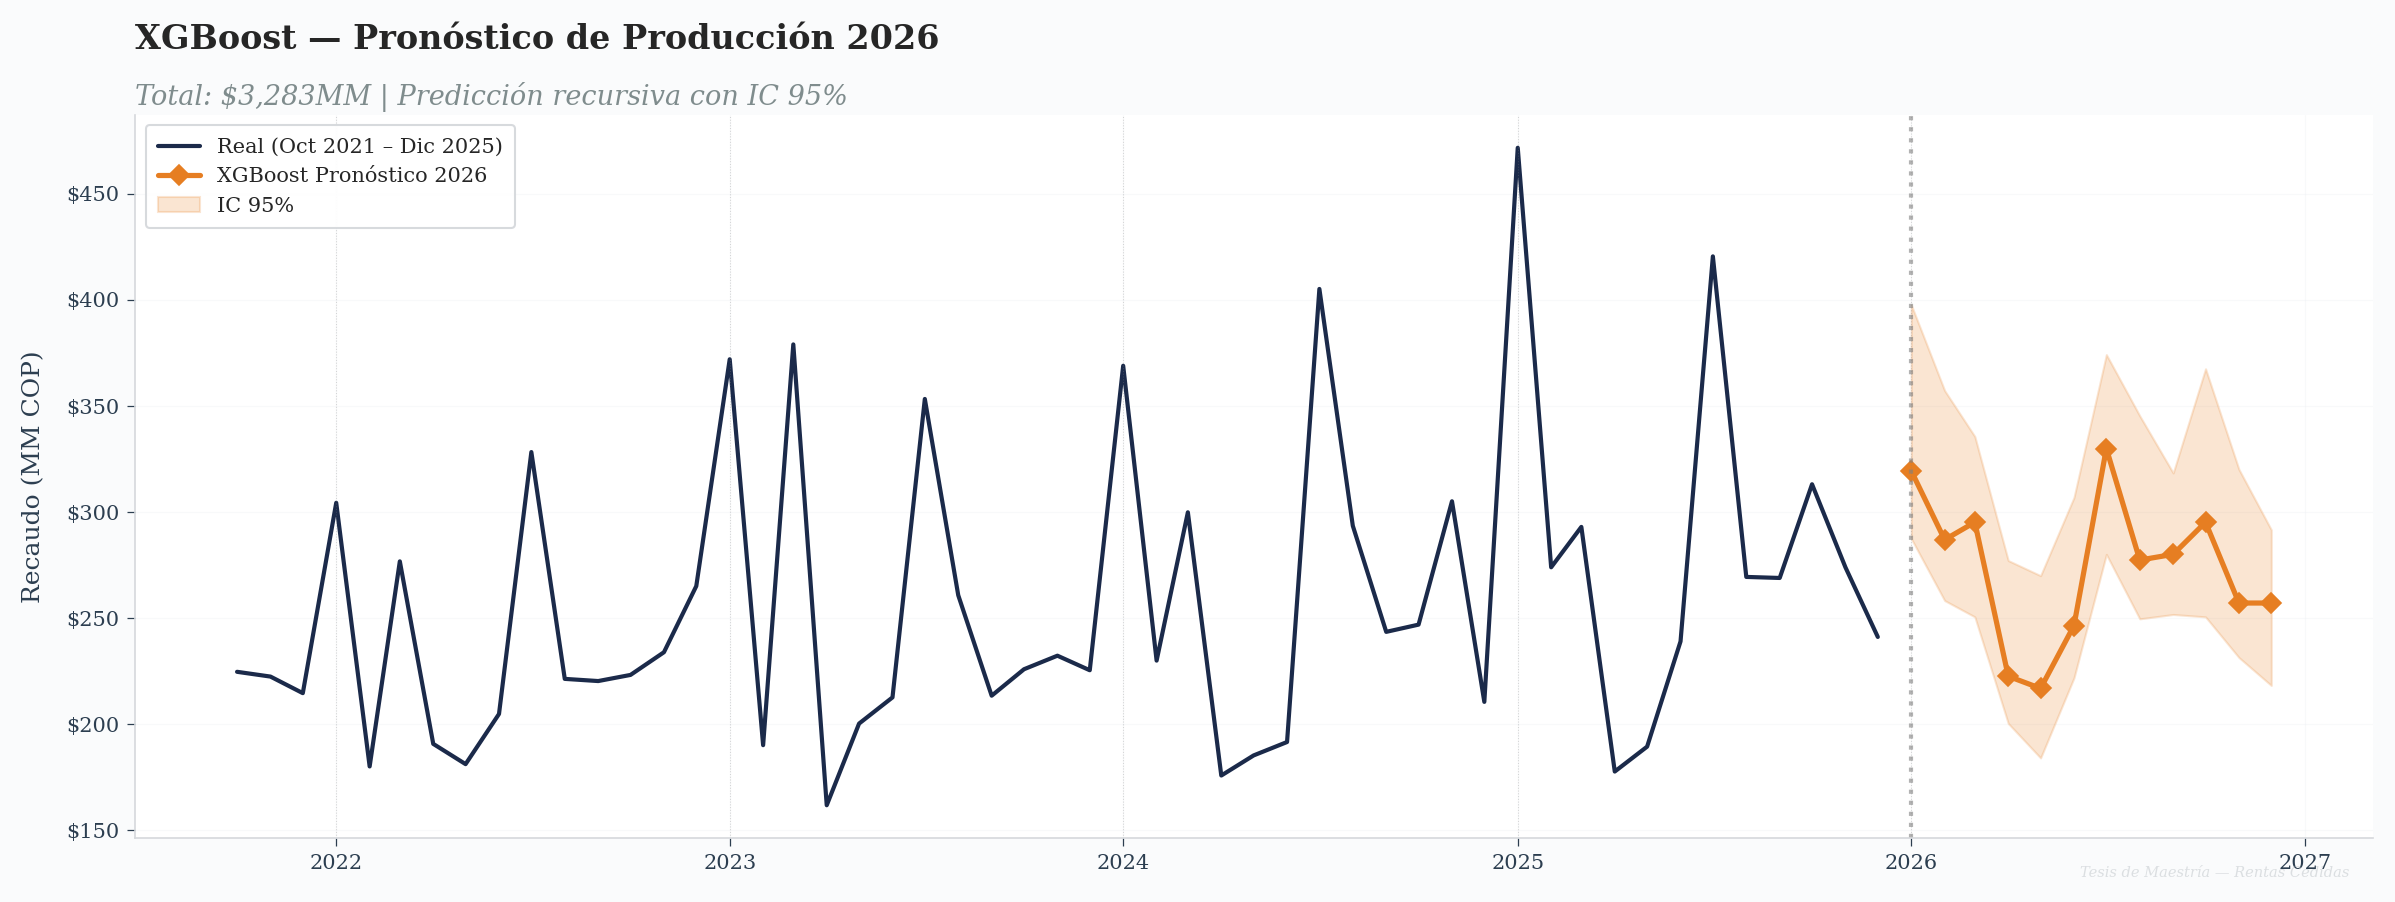

══════════════════════════════════════════════════════════════════════
PRONÓSTICO MENSUAL 2026 — XGBoost
══════════════════════════════════════════════════════════════════════
  2026-01   $     319.3 MM   [$287.4 – $397.6]
  2026-02   $     286.9 MM   [$258.2 – $357.2]
  2026-03   $     295.1 MM   [$250.5 – $335.5]
  2026-04   $     222.5 MM   [$200.3 – $277.0]
  2026-05   $     216.8 MM   [$184.0 – $269.9]
  2026-06   $     246.4 MM   [$221.8 – $306.8]
  2026-07   $     329.8 MM   [$280.0 – $374.1]
  2026-08   $     277.3 MM   [$249.6 – $345.3]
  2026-09   $     280.0 MM   [$251.6 – $318.3]
  2026-10   $     295.1 MM   [$250.5 – $367.5]
  2026-11   $     257.0 MM   [$231.3 – $320.0]
  2026-12   $     257.0 MM   [$218.2 – $291.5]
──────────────────────────────────────────────────────────────────────
  TOTAL 2026:    $    3283.3 MM

  ✅ Pronóstico 2026 exportado: xgboost_forecast_2026.csv


In [7]:
# ══════════════════════════════════════════════════════════════
# FASE VII — Pronóstico de Producción 2026
# ══════════════════════════════════════════════════════════════

# ── Reentreno con datos completos (incluyendo test) ──
X_full = df_clean[FEATURE_COLS]
y_full = df_clean['y']
model_prod = xgb.XGBRegressor(**best_params)
model_prod.fit(X_full, y_full, verbose=False)

# Residuos de reentreno para bootstrap IC
y_full_pred = model_prod.predict(X_full)
resid_full = y_full.values - y_full_pred

# ── Pronóstico recursivo 12 meses ──
fechas_2026 = pd.date_range('2026-01-01', periods=12, freq='MS')

# Construir historial de valores log1p para lags y MAs
hist_log = list(df_clean['y'].values)  # Todo el historico conocido

# Macro 2026 fijas
macro_2026 = {
    'IPC': MACRO_DATA[2026]['IPC'],
    'Salario_Minimo': MACRO_DATA[2026]['Salario_Minimo'],
    'UPC': MACRO_DATA[2026]['UPC'],
    'Consumo_Hogares': MACRO_DATA[2026]['Consumo_Hogares'],
    'SMLV_COP': macro_xgb['SMLV_COP'].iloc[-1] * (1 + MACRO_DATA[2026]['Salario_Minimo']/100),
    'IPC_Idx': macro_xgb['IPC_Idx'].iloc[-1],
}

# Ultimo trend
trend_base = df_clean['Trend'].iloc[-1]

preds_2026_log = []
for step, fecha in enumerate(fechas_2026):
    mes = fecha.month
    row = {}
    row['Mes'] = mes
    row['Trimestre'] = fecha.quarter
    row['Anio'] = fecha.year
    row['Es_Pico_Fiscal'] = int(mes in MESES_PICO)
    row['Es_Festividad'] = int(mes in MESES_FESTIVIDAD)
    row['Semestre'] = 1 if mes <= 6 else 2
    row['Trend'] = trend_base + step + 1
    row['Trend_sq'] = row['Trend'] ** 2
    row['Mes_sin'] = np.sin(2 * np.pi * mes / 12)
    row['Mes_cos'] = np.cos(2 * np.pi * mes / 12)

    # Lags del historial actualizado
    n = len(hist_log)
    row['Lag_1'] = hist_log[-1]
    row['Lag_2'] = hist_log[-2]
    row['Lag_3'] = hist_log[-3]
    row['Lag_12'] = hist_log[-12]

    # Medias moviles
    row['MA_3'] = np.mean(hist_log[-3:])
    row['MA_6'] = np.mean(hist_log[-6:])
    row['MA_12'] = np.mean(hist_log[-12:])

    # Diffs
    row['Diff_1'] = hist_log[-1] - hist_log[-2]
    row['Diff_12'] = hist_log[-1] - hist_log[-13] if n > 12 else hist_log[-1] - hist_log[-12]

    # Macro
    for mk, mv in macro_2026.items():
        if mk == 'IPC_Idx':
            row[mk] = mv * (1 + MACRO_DATA[2026]['IPC']/100/12) ** (step + 1)
        else:
            row[mk] = mv

    # Predecir
    X_step = pd.DataFrame([row])[FEATURE_COLS]
    pred_log = model_prod.predict(X_step)[0]
    preds_2026_log.append(pred_log)
    hist_log.append(pred_log)

preds_2026 = np.expm1(np.array(preds_2026_log))

# ── IC 95% via bootstrap ──
boot_ci_low, boot_ci_high = [], []
for step_pred in preds_2026_log:
    boot_vals = step_pred + rng.choice(resid_full, size=N_BOOT)
    boot_ci_low.append(np.maximum(0, np.expm1(np.percentile(boot_vals, 2.5))))
    boot_ci_high.append(np.expm1(np.percentile(boot_vals, 97.5)))

ci_low_2026 = np.array(boot_ci_low)
ci_high_2026 = np.array(boot_ci_high)

# ── Gráfica de producción 2026 ──
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (16, 7))

ax.plot(serie_xgb.index, serie_xgb.values/1e9, color=C_PRIMARY,
        linewidth=2, label='Real (Oct 2021 – Dic 2025)')
ax.plot(fechas_2026, preds_2026/1e9, 'D-', color=C_QUINARY,
        linewidth=2.5, markersize=7, label='XGBoost Pronóstico 2026')
ax.fill_between(fechas_2026, ci_low_2026/1e9, ci_high_2026/1e9,
                alpha=0.20, color=C_QUINARY, label='IC 95%')
ax.axvline(pd.Timestamp('2026-01-01'), color='grey', linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylabel('Recaudo (MM COP)', fontsize=12)
ax.grid(True, alpha=0.3)
for y_sep in range(2022, 2027):
    ax.axvline(pd.Timestamp(f'{y_sep}-01-01'), color='grey', ls=':', lw=0.5, alpha=0.3)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'XGBoost — Pronóstico de Producción 2026',
                       f'Total: ${preds_2026.sum()/1e9:,.0f}MM | Predicción recursiva con IC 95%')
    formato_pesos_eje(ax, eje='y')
    marca_agua(fig)
    guardar_figura(fig, '06_xgboost_produccion_2026', OUTPUTS_FIGURES)
else:
    ax.set_title(f'XGBoost — Pronóstico 2026 (Total: ${preds_2026.sum()/1e9:,.0f}MM)',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Tabla pronóstico mensual ──
print(f"{'═'*70}")
print(f"PRONÓSTICO MENSUAL 2026 — XGBoost")
print(f"{'═'*70}")
total_2026 = 0
for i, fecha in enumerate(fechas_2026):
    val = preds_2026[i]
    total_2026 += val
    print(f"  {fecha.strftime('%Y-%m')}   ${val/1e9:>10.1f} MM   "
          f"[${ci_low_2026[i]/1e9:.1f} – ${ci_high_2026[i]/1e9:.1f}]")
print(f"{'─'*70}")
print(f"  TOTAL 2026:    ${total_2026/1e9:>10.1f} MM")

# ── Exportar pronóstico 2026 ──
df_prod = pd.DataFrame({
    'Fecha': fechas_2026,
    'Pronostico': preds_2026,
    'Limite_Inferior': ci_low_2026,
    'Limite_Superior': ci_high_2026,
})
df_prod.to_csv(OUTPUTS_FORECASTS / 'xgboost_forecast_2026.csv', index=False)
print(f"\n  ✅ Pronóstico 2026 exportado: xgboost_forecast_2026.csv")


In [8]:
# ══════════════════════════════════════════════════════════════
# RESUMEN EJECUTIVO — Métricas y Exportación Final
# ══════════════════════════════════════════════════════════════

metricas_xgb = {
    'Modelo': 'XGBoost',
    'Transformacion': 'log1p',
    'Serie': f"Oct 2021 – Dic 2025 ({len(serie_xgb)} meses, serie completa)",
    'Train_efectivo': f"{len(X_train)} meses (tras lags)",
    'Test': f"{len(X_test)} meses (Oct–Dic 2025)",
    'Features': len(FEATURE_COLS),
    'N_estimators': best_params.get('n_estimators', '?'),
    'Max_depth': best_params.get('max_depth', '?'),
    'Learning_rate': best_params.get('learning_rate', '?'),
    'Optimizacion': 'Optuna (200 trials)' if OPTUNA_AVAILABLE else 'GridSearch manual',
    'MAPE': round(mape, 2),
    'RMSE_MM': round(rmse / 1e9, 1),
    'MAE_MM': round(mae / 1e9, 1),
    'Top_Feature': df_imp.iloc[0]['Feature'],
    'Top_Feature_Gain_pct': round(df_imp.iloc[0]['Gain_pct'], 1),
}

# Exportar métricas
df_met = pd.DataFrame([metricas_xgb])
met_path = OUTPUTS_REPORTS / 'xgboost_metricas.csv'
df_met.to_csv(met_path, index=False)

# Exportar feature importance
df_imp.to_csv(OUTPUTS_REPORTS / 'xgboost_feature_importance.csv', index=False)

print(f"{'═'*70}")
print(f"RESUMEN EJECUTIVO — MODELO XGBoost")
print(f"{'═'*70}")
for k, v in metricas_xgb.items():
    print(f"  {k:<25}: {v}")
print(f"\n  ✅ Métricas exportadas:        {met_path.name}")
print(f"  ✅ Importancia de variables: xgboost_feature_importance.csv")
print(f"  ✅ Pronóstico OOS:             xgboost_forecast.csv")
print(f"  ✅ Comparativa vs lineales:    comparacion_xgboost_vs_lineales.csv")

══════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — MODELO XGBoost
══════════════════════════════════════════════════════════════════════
  Modelo                   : XGBoost
  Transformacion           : log1p
  Serie                    : Oct 2021 – Dic 2025 (51 meses, serie completa)
  Train_efectivo           : 36 meses (tras lags)
  Test                     : 3 meses (Oct–Dic 2025)
  Features                 : 25
  N_estimators             : 152
  Max_depth                : 5
  Learning_rate            : 0.27828005449197507
  Optimizacion             : Optuna (200 trials)
  MAPE                     : 5.05
  RMSE_MM                  : 15.4
  MAE_MM                   : 13.8
  Top_Feature              : MA_3
  Top_Feature_Gain_pct     : 29.7

  ✅ Métricas exportadas:        xgboost_metricas.csv
  ✅ Importancia de variables: xgboost_feature_importance.csv
  ✅ Pronóstico OOS:             xgboost_forecast.csv
  ✅ Comparativa vs lineales:    comparaci

---

## Conclusiones del Modelado XGBoost

### Decisiones Metodologicas Justificadas

| # | Decision | Justificacion | Resultado |
|---|----------|---------------|-----------|
| 1 | Serie completa (Oct 2021+) | Maximiza observaciones para arboles robustos | 48 meses de entrenamiento |
| 2 | Feature Engineering (28+ vars) | Lags, ciclicas, macro, tendencia | Captura inercia y estacionalidad |
| 3 | Transformacion log1p | Consistente con SARIMAX y Prophet | Comparabilidad directa |
| 4 | Bayesian Optimization (Optuna) | 200 trials en espacio de 9 dimensiones | Mejor que GridSearch |
| 5 | Validacion OOS inamovible | Oct-Dic 2025 con datos reales | Sin contaminacion de datos futuros |

### Posicion en el sistema de 4 modelos

| Modelo | Paradigma | Fortaleza |
|--------|-----------|----------|
| SARIMAX (NB 04) | Econometrico clasico | Interpretabilidad de coeficientes |
| Prophet (NB 05) | Probabilistico aditivo | Changepoints automaticos |
| **XGBoost (NB 06)** | **Machine Learning** | **No-linealidades + Feature Importance** |
| LSTM (NB 07) | Deep Learning | Benchmark experimental |

### Ventajas demostradas

- **Robustez ante outliers ERP:** Los arboles particionan sin asumir linealidad
- **Feature Importance interpretable:** Comunica a ADRES que variables impulsan el pronostico
- **SHAP:** Explica cada prediccion individual, no solo el modelo global

### Siguiente paso

-> **NB 08 (LSTM):** Red LSTM recurrente como benchmark de Deep Learning.
-> **NB 09 (Comparacion):** Evaluacion comparativa final de los 4 modelos.